# **Projet 3 - Prédiction de la consommation énergétique des bâtiments de Seattle**

 * Prédire la consommation énergétique des bâtiments non résidentiels de Seattle à partir de leurs caractéristiques structurelles.
 * Réaliser une analyse exploratoire afin d'identifier les principales tendances et anomalies des données.
 * Comparer plusieurs modèles de régression supervisée pour sélectionner le plus performant.
 * Identifier les variables ayant le plus d'influence sur la consommation énergétique.*
 

## **Contexte** 

* La ville de Seattle souhaite atteindre la neutralité carbone d'ici 2050.
* Les relevés énergétiques des bâtiments sont coûteux à réaliser et ne sont pas disponibles pour l'ensemble du parc immobilier.
* L'objectif est d'utiliser les données collectées en 2016 afin d'estimer la consommation énergétique des bâtiments non encore mesurés.*

## **Objectfs Data** 
- **Comprendre le jeu de données :** analyser la structure, les types de variables, les valeurs manquantes et la qualité des données.
- **Nettoyer et préparer les données :** sélectionner les bâtiments non résidentiels, traiter les incohérences et préparer les variables pour la modélisation.
- **Réaliser une analyse exploratoire (EDA) :** identifier les distributions, les corrélations et les facteurs susceptibles d'influencer la consommation énergétique.
- **Construire et comparer plusieurs modèles de régression** afin de prédire la consommation énergétique des bâtiments.
- **Interpréter le modèle retenu :** analyser l'importance des variables explicatives et identifier les principaux facteurs influençant la consommation énergétique.

## **Partie 1** 

### **Étape 1- Réalisez une analyse exploratoire**

qsdqsdq


In [1]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


#### **Chargement des bases des données**
- Importation des 5 bases de données disponibles au format .csv dans le dossier local.

In [2]:
base_path = "../data"

dfData = pd.read_csv(base_path + "/EdStatsData.csv")
dfSeries = pd.read_csv(base_path + "/EdStatsSeries.csv")
dfFoot = pd.read_csv(base_path + "/EdStatsFootNote.csv")
dfCountry_series = pd.read_csv(base_path + "/EdStatsCountry-Series.csv")
dfStats_country = pd.read_csv(base_path + "/EdStatsCountry.csv")

### **Étape 2 - Collectez des informations basiques sur chaque jeu de données**

#### **Analyse exploratoire de la base "EdStatsData"**

- Les données annuelles sont présentées en colonnes et les lignes contiennent des informations sur le pays, le code de référence et le nom de l'indicateur.
- Chaque ligne correspond à un pays et un indicateur spécifique.  
- La ligne 1 indique que le Zimbabwe est un pays dont l'indicateur porte sur la population Male âgée de 15 à 24 ans. Cependant, les colonnes correspondant aux années 1970 à 2100 contiennent des données manquantes ou inconnues (NaN).

##### **Dimensions**

In [3]:
# Aperçu premiéres 5 lignes

dfData.shape

(886930, 70)

In [4]:
# Aperçu premiéres 5 lignes

dfData.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Aperçu derniéres 5 lignes

dfData.tail()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
886925,Zimbabwe,ZWE,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886926,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886927,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886928,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886929,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, m...",SE.ADT.1524.LT.MA.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("La base de données contient", dfData.shape[0], "lignes et", dfData.shape[1], "colonnes.")

La base de données contient 886930 lignes et 70 colonnes.


In [7]:
dfData.describe()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
count,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,3.748300e+04,3.757400e+04,3.757600e+04,3.680900e+04,...,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,0.0
mean,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,5.731808e+09,6.124437e+09,6.671489e+09,7.436724e+09,...,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02,NaN
std,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,2.215546e+11,2.325489e+11,2.473986e+11,2.660957e+11,...,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04,NaN
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,...,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01,NaN
25%,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,9.312615e+00,9.519913e+00,1.000000e+01,1.000000e+01,...,3.000000e-02,3.000000e-02,2.000000e-02,2.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,NaN
50%,6.317724e+00,6.316240e+01,6.655139e+01,6.969595e+01,7.087760e+01,9.677420e+00,7.101590e+01,7.133326e+01,7.290512e+01,7.510173e+01,...,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.200000e-01,NaN
75%,6.251250e+01,5.655200e+04,5.863650e+04,6.202900e+04,6.383675e+04,7.854163e+01,5.682800e+04,5.739175e+04,5.940425e+04,6.411500e+04,...,7.505000e+00,7.500000e+00,7.300000e+00,7.100000e+00,6.722500e+00,6.080000e+00,5.462500e+00,4.680000e+00,4.032500e+00,NaN
max,1.903929e+13,1.986457e+13,2.100916e+13,2.238367e+13,2.282991e+13,2.300634e+13,2.424128e+13,2.521383e+13,2.622101e+13,2.730873e+13,...,2.951569e+06,3.070879e+06,3.169711e+06,3.246239e+06,3.301586e+06,3.337871e+06,3.354746e+06,3.351887e+06,3.330484e+06,NaN


In [8]:
dfData.info()

<class 'pandas.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  str    
 1   Country Code    886930 non-null  str    
 2   Indicator Name  886930 non-null  str    
 3   Indicator Code  886930 non-null  str    
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  1982            37511 non-null   float64
 17  1983            38460

##### **Types de données**

- Les variables catégorielles des colonnes "Country Name" à "Indicator Code", sont correctement typées en object;
- Les séries temporelles sont en float64, ce qui est adapté à la présence de décimales et de valeurs manquantes.
- La colonne "Unamed: 69" ne contient pas d’information exploitable.

In [9]:
# Types de données
dfData.dtypes

Country Name          str
Country Code          str
Indicator Name        str
Indicator Code        str
1970              float64
                   ...   
2085              float64
2090              float64
2095              float64
2100              float64
Unnamed: 69       float64
Length: 70, dtype: object

In [10]:
dfData.shape

(886930, 70)

##### **Doublons**
La base de données ne contient pas de lignes en double, il n'y a donc pas besoin d'ajustements ni de nettoyage des données.

In [11]:
dfData.duplicated().sum()

np.int64(0)

In [12]:
dfData.shape

(886930, 70)

##### **Valeurs manquantes**
- Parmi les colonnes de Type "Object" il ne semble pas d'avoir valeurs manquantes;
- Les colonnes "Float" de valeurs temporelles a partir de 1970 ont plus de 90% du totale des valeurs sont manquantes ce qui est cohérent avec des séries historiques selon chaque pays et indicateur.
- La colonne "Unnamed: 69" a 100% des valeurs manquantes.

In [13]:
# Calcul du pourcentage moyen de valeurs manquantes par colonne
dfData.isna().mean()

Country Name      0.000000
Country Code      0.000000
Indicator Name    0.000000
Indicator Code    0.000000
1970              0.918496
                    ...   
2085              0.942007
2090              0.942007
2095              0.942007
2100              0.942007
Unnamed: 69       1.000000
Length: 70, dtype: float64

In [14]:
# Pourcentage de valeurs manquantes par colonne.

missing_pct = (dfData.isna().mean() * 100)


##### **Suppression des colonnes inutilisables**
- Parmi les informations manquantes, les colonnes avec plus de 95 % des valeurs manquantes seront supriimés
- Nombre de colonnes à supprimer : 19
- Aprés ce nettoyage la base de données est desormais 51 colonnes.

In [15]:
# Visualisation des colonnes avec plus de 95 % de valeurs manquantes a la fin des les supprimer

cols_more_95 = missing_pct[missing_pct > 95]

cols_more_95.sort_values(ascending=False)

Unnamed: 69    100.000000
2017            99.983877
2016            98.144160
1971            95.993258
1973            95.992356
1972            95.984012
1974            95.971497
1979            95.849842
1976            95.773849
1982            95.770692
1989            95.767422
1977            95.763589
1978            95.763364
1983            95.663694
1988            95.653321
1984            95.647233
1987            95.643286
1981            95.627953
1986            95.560867
dtype: float64

In [16]:
# Contabilisation du nombre de colonnes à supprimer

print(f"Nombre de colonnes à supprimer : {len(cols_more_95)}")

Nombre de colonnes à supprimer : 19


In [17]:
# Suppression des colonnes avec plus de 95 % de valeurs manquantes

dfData = dfData.drop(columns=cols_more_95.index)

In [18]:
print(dfData.describe())

               1970          1975          1980          1985          1990  \
count  7.228800e+04  8.730600e+04  8.912200e+04  9.029600e+04  1.244050e+05   
mean   1.974772e+09  2.314288e+09  3.283898e+09  3.622763e+09  9.084424e+09   
std    1.211687e+11  1.375059e+11  1.780774e+11  2.002929e+11  3.665667e+11   
min   -1.435564e+00 -3.658569e+00 -1.404240e+00 -2.216315e+00 -1.803750e+00   
25%    8.900000e-01  1.400000e+00  1.770000e+00  2.150000e+00  4.830000e+00   
50%    6.317724e+00  9.677420e+00  1.107000e+01  1.200000e+01  5.048379e+01   
75%    6.251250e+01  7.854163e+01  8.202760e+01  8.338313e+01  9.134300e+04   
max    1.903929e+13  2.300634e+13  2.784319e+13  3.166465e+13  4.714344e+13   

               1991          1992          1993          1994          1995  \
count  7.443700e+04  7.554300e+04  7.579300e+04  7.746200e+04  1.313610e+05   
mean   1.571674e+10  1.604668e+10  1.643532e+10  1.684022e+10  1.052543e+10   
std    4.881357e+11  5.012055e+11  5.121962e+11  5.

In [19]:
print(dfData.shape)

(886930, 51)


In [20]:
# visualisation des colonnes a la fin de verifier l'exclusion des colonnes avec plus de 95 % de valeurs manquantes

dfData.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1970', '1975', '1980', '1985', '1990', '1991', '1992', '1993', '1994',
       '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2020', '2025', '2030', '2035', '2040', '2045',
       '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090',
       '2095', '2100'],
      dtype='str')

In [21]:
#Revisualisation Shape de la base de données après nettoyage des noms de colonnes
dfData.shape

(886930, 51)

##### **Standardisation des colonnes**
- Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques.

In [22]:
# visualisation des colonnes
dfData.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1970', '1975', '1980', '1985', '1990', '1991', '1992', '1993', '1994',
       '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2020', '2025', '2030', '2035', '2040', '2045',
       '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090',
       '2095', '2100'],
      dtype='str')

In [23]:
#Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques

dfData.columns = (
    dfData.columns
    .str.lower()                  # minúsculas
    .str.strip()                  # remove espaços extras
    .str.replace(" ", "_")        # espaço -> _
    .str.replace("-", "_")        # hífen -> _
)

In [24]:
#Revisualisation des colonnes dans une version standardisée

dfData.columns

Index(['country_name', 'country_code', 'indicator_name', 'indicator_code',
       '1970', '1975', '1980', '1985', '1990', '1991', '1992', '1993', '1994',
       '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2020', '2025', '2030', '2035', '2040', '2045',
       '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090',
       '2095', '2100'],
      dtype='str')

In [25]:
#Revisualisation Shape de la base de données après standardisation des noms de colonnes
dfData.shape

(886930, 51)

##### **Statistiques descriptives**
- Comme il s’agit d’une base de données annuelle par pays, certaines informations ne sont pas disponibles pour tous les pays ou toutes les années.
- Il existe des différences importantes entre les valeurs minimales et maximales, les résultats restent cohérents pour une base de données historique contenant plusieurs indicateurs par pays.

In [26]:
pd.set_option('display.float_format', '{:.2f}'.format)

dfData.describe()

,1970,1975,1980,1985,1990,1991,1992,1993,1994,1995,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
count,72288.00,87306.00,89122.00,90296.00,124405.00,74437.00,75543.00,75793.00,77462.00,131361.00,...,51436.00,51436.00,51436.00,51436.00,51436.00,51436.00,51436.00,51436.00,51436.00,51436.00
mean,1974772449.59,2314287511.57,3283897508.64,3622763069.55,9084423550.66,15716740023.54,16046684980.91,16435324911.56,16840220344.07,10525426793.16,...,714.58,722.49,727.13,728.38,726.65,722.83,717.69,711.31,703.43,694.03
std,121168685351.94,137505922744.68,178077355006.15,200292918506.93,366566685061.90,488135688946.06,501205532249.85,512196248891.19,529298242836.15,428521845883.65,...,21368.51,22158.45,22879.90,23523.38,24081.49,24558.97,24965.87,25301.83,25560.69,25741.89
min,-1.44,-3.66,-1.40,-2.22,-1.80,-5.81,-5.09,-6.18,-4.79,-2.70,...,-1.83,-1.63,-1.44,-1.26,-1.09,-0.92,-0.78,-0.65,-0.55,-0.45
25%,0.89,1.40,1.77,2.15,4.83,51.35,49.34,49.45,47.83,5.20,...,0.03,0.03,0.03,0.02,0.02,0.01,0.01,0.01,0.01,0.01
50%,6.32,9.68,11.07,12.00,50.48,39160.00,34773.00,34971.00,31825.00,50.19,...,0.23,0.23,0.23,0.23,0.23,0.23,0.23,0.23,0.23,0.22
75%,62.51,78.54,82.03,83.38,91343.00,438313.00,424612.50,431625.00,424460.48,79540.00,...,7.50,7.50,7.50,7.30,7.10,6.72,6.08,5.46,4.68,4.03
max,19039286948196.10,23006343161670.40,27843189307931.60,31664646793713.80,47143438466903.20,47812717689115.00,48664457634800.10,49596000966258.90,51065807538866.00,52754475204801.00,...,2813669.77,2951568.84,3070878.84,3169710.61,3246239.22,3301586.19,3337871.21,3354746.27,3351886.89,3330483.54


In [27]:
dfData.shape

(886930, 51)

##### **Variables catégorielles**
- Les colonnes `country_name` et `country_code` comportent 242 modalités distinctes correspondant aux pays et régions présents dans la base de données.
- Les colonnes `indicator_name` et `indicator_code` comportent 3 665 modalités distinctes.
- Chaque indicateur est renseigné pour les 242 pays ou régions de la base de données.

In [28]:
dfData.dtypes

country_name          str
country_code          str
indicator_name        str
indicator_code        str
1970              float64
1975              float64
1980              float64
1985              float64
1990              float64
1991              float64
1992              float64
1993              float64
1994              float64
1995              float64
1996              float64
1997              float64
1998              float64
1999              float64
2000              float64
2001              float64
2002              float64
2003              float64
2004              float64
2005              float64
2006              float64
2007              float64
2008              float64
2009              float64
2010              float64
2011              float64
2012              float64
2013              float64
2014              float64
2015              float64
2020              float64
2025              float64
2030              float64
2035              float64
2040        

In [29]:
dfData.shape

(886930, 51)

#### **Analyse exploratoire de la base "EdStatsSeries"**

- La base de données "EdStatsSeries" contient des informations descriptives sur les indicateurs.
- Chaque ligne correspond à un indicateur spécifique avec des détails généraux, comme la source, la périodicité ou la description de l’indicateur.
- La colonne "Series Code" semble être reliée à la colonne "Indicator Code" de la base de données "EdStatsData".

##### **Dimensions**

In [30]:
# Aperçu premiéres 5 lignes

dfSeries.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# Aperçu derniéres 5 lignes

dfSeries.tail()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
3660,UIS.XUNIT.USCONST.3.FSGOV,Expenditures,Government expenditure per upper secondary stu...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3661,UIS.XUNIT.USCONST.4.FSGOV,Expenditures,Government expenditure per post-secondary non-...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3662,UIS.XUNIT.USCONST.56.FSGOV,Expenditures,Government expenditure per tertiary student (c...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663,XGDP.23.FSGOV.FDINSTADM.FFD,Expenditures,Government expenditure in secondary institutio...,"Total general (local, regional and central) go...","Total general (local, regional and central) go...",NaN,NaN,NaN,Secondary,NaN,...,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3664,XGDP.56.FSGOV.FDINSTADM.FFD,Expenditures,Government expenditure in tertiary institution...,"Total general (local, regional and central) go...","Total general (local, regional and central) go...",NaN,NaN,NaN,Tertiary,NaN,...,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# Dimensions du jeu de données
print("La base de données contient", dfSeries.shape[0], "lignes et", dfSeries.shape[1], "colonnes.")

La base de données contient 3665 lignes et 21 colonnes.


In [33]:
# Statistiques descriptives des variables numériques

dfSeries.describe()

,Unit of measure,Notes from original source,Other web links,Related indicators,License Type,Unnamed: 20
count,0.00,0.00,0.00,0.00,0.00,0.00
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# Informations générales sur les colonnes et les types de données

dfSeries.info()

<class 'pandas.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Series Code                          3665 non-null   str    
 1   Topic                                3665 non-null   str    
 2   Indicator Name                       3665 non-null   str    
 3   Short definition                     2156 non-null   str    
 4   Long definition                      3665 non-null   str    
 5   Unit of measure                      0 non-null      float64
 6   Periodicity                          99 non-null     str    
 7   Base Period                          314 non-null    str    
 8   Other notes                          552 non-null    str    
 9   Aggregation method                   47 non-null     str    
 10  Limitations and exceptions           14 non-null     str    
 11  Notes from original source           0 no

In [35]:
# Vérification de la structure du DataFrame

dfSeries.shape

(3665, 21)

##### **Types de données**

- Le jeu de données contient 15 colonnes de type texte (`str`) et 6 colonnes de type numérique (`float64`).
- Les colonnes textuelles contiennent des informations descriptives relatives aux indicateurs.

In [36]:
# Types de données
dfSeries.dtypes

Series Code                                str
Topic                                      str
Indicator Name                             str
Short definition                           str
Long definition                            str
Unit of measure                        float64
Periodicity                                str
Base Period                                str
Other notes                                str
Aggregation method                         str
Limitations and exceptions                 str
Notes from original source             float64
General comments                           str
Source                                     str
Statistical concept and methodology        str
Development relevance                      str
Related source links                       str
Other web links                        float64
Related indicators                     float64
License Type                           float64
Unnamed: 20                            float64
dtype: object

##### **Doublons**
La base de données ne contient pas de lignes en double, il n'y a donc pas besoin d'ajustements ni de nettoyage des données.

In [37]:
dfSeries.duplicated().sum()

np.int64(0)

##### **Valeurs manquantes**
- 11 des 20 colonnes présentent > 95 % de valeurs manquantes. Ces informations semblent être des champs optionnels et ne seront probablement pas exploitables pour l’analyse.

In [38]:
# Calcul du pourcentage moyen de valeurs manquantes par colonne
dfSeries.isna().mean()

Series Code                           0.00
Topic                                 0.00
Indicator Name                        0.00
Short definition                      0.41
Long definition                       0.00
Unit of measure                       1.00
Periodicity                           0.97
Base Period                           0.91
Other notes                           0.85
Aggregation method                    0.99
Limitations and exceptions            1.00
Notes from original source            1.00
General comments                      1.00
Source                                0.00
Statistical concept and methodology   0.99
Development relevance                 1.00
Related source links                  0.94
Other web links                       1.00
Related indicators                    1.00
License Type                          1.00
Unnamed: 20                           1.00
dtype: float64

In [39]:
# Pourcentage de valeurs manquantes par colonne.

missing_pct = (dfSeries.isna().mean() * 100)


In [40]:
# Visualisation des colonnes avec plus de 95 % de valeurs manquantes a la fin des les supprimer

cols_more_95 = missing_pct[missing_pct > 95]

cols_more_95.sort_values(ascending=False)

Unit of measure                       100.00
Related indicators                    100.00
License Type                          100.00
Notes from original source            100.00
Unnamed: 20                           100.00
Other web links                       100.00
Development relevance                  99.92
Limitations and exceptions             99.62
General comments                       99.62
Statistical concept and methodology    99.37
Aggregation method                     98.72
Periodicity                            97.30
dtype: float64

In [41]:
# Contabilisation du nombre de colonnes à supprimer

print(f"Nombre de colonnes à supprimer : {len(cols_more_95)}")

Nombre de colonnes à supprimer : 12


##### **Suppression des colonnes inutilisables**
- Parmi les informations manquantes, la colonne "Unnamed: 20" a été supprimeé.
- Aprés ce nettoyage la base de données est desormais 20 colonnes.

In [42]:
# Suppression des colonnes avec plus de 95 % de valeurs manquantes

dfSeries = dfSeries.drop(columns=cols_more_95.index)

In [43]:
print(dfSeries.describe())

                Series Code              Topic  \
count                  3665               3665   
unique                 3665                 37   
top     BAR.NOED.1519.FE.ZS  Learning Outcomes   
freq                      1               1046   

                                           Indicator Name  \
count                                                3665   
unique                                               3665   
top     Barro-Lee: Percentage of female population age...   
freq                                                    1   

                                         Short definition  \
count                                                2156   
unique                                               1169   
top     Data Interpretation: 1=Latent; 2=Emerging; 3=E...   
freq                                                  215   

                                          Long definition  \
count                                                3665   
unique         

In [44]:
print(dfSeries.shape)

(3665, 9)


##### **Statistiques descriptives**
- Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques.

In [45]:
# visualisation des colonnes
dfSeries.columns

Index(['Series Code', 'Topic', 'Indicator Name', 'Short definition',
       'Long definition', 'Base Period', 'Other notes', 'Source',
       'Related source links'],
      dtype='str')

In [46]:
#Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques

dfSeries.columns = (
    dfSeries.columns
    .str.lower()                  # minúsculas
    .str.strip()                  # remove espaços extras
    .str.replace(" ", "_")        # espaço -> _
    .str.replace("-", "_")        # hífen -> _
)

In [47]:
#Revisualisation des colonnes dans une version standardisée
dfSeries.columns

Index(['series_code', 'topic', 'indicator_name', 'short_definition',
       'long_definition', 'base_period', 'other_notes', 'source',
       'related_source_links'],
      dtype='str')

In [48]:
#Revisualisation Shape de la base de données après nettoyage et standardisation des noms de colonnes
dfSeries.shape

(3665, 9)

##### **Statistiques descriptives**
- On observe que les données de la table dfSeries contiennent principalement des informations descriptives et textuelles, comme les sources, les détails des indicateurs et leurs descriptions.

In [49]:
dfSeries.describe(include='all')

,series_code,topic,indicator_name,short_definition,long_definition,base_period,other_notes,source,related_source_links
count,3665,3665,3665,2156,3665,314,552,3665,215
unique,3665,37,3665,1169,2060,4,14,31,1
top,BAR.NOED.1519.FE.ZS,Learning Outcomes,Barro-Lee: Percentage of female population age...,Data Interpretation: 1=Latent; 2=Emerging; 3=E...,Data Interpretation: 1=Latent; 2=Emerging; 3=E...,Projections (2010 to 2100),EGRA,UNESCO Institute for Statistics,http://saber.worldbank.org/index.cfm
freq,1,1046,1,215,215,308,403,1269,215


##### **Variables catégorielles**
- Les colonnes "Series Code" et "Indicator Name" contiennent des codes uniques pour chaque indicateur.
- Dans la colonne "Topic", les indicateurs sont généralement liés à l’éducation.
- Dans la colonne "Source", l’UNESCO est la source la plus mentionnée.

In [50]:
dfSeries["series_code"].value_counts()

series_code
BAR.NOED.1519.FE.ZS            1
BAR.NOED.1519.ZS               1
BAR.NOED.15UP.FE.ZS            1
BAR.NOED.15UP.ZS               1
BAR.NOED.2024.FE.ZS            1
                              ..
UIS.XUNIT.USCONST.3.FSGOV      1
UIS.XUNIT.USCONST.4.FSGOV      1
UIS.XUNIT.USCONST.56.FSGOV     1
XGDP.23.FSGOV.FDINSTADM.FFD    1
XGDP.56.FSGOV.FDINSTADM.FFD    1
Name: count, Length: 3665, dtype: int64

In [51]:
dfSeries["indicator_name"].value_counts()

indicator_name
Barro-Lee: Percentage of female population age 15-19 with no education           1
Barro-Lee: Percentage of population age 15-19 with no education                  1
Barro-Lee: Percentage of female population age 15+ with no education             1
Barro-Lee: Percentage of population age 15+ with no education                    1
Barro-Lee: Percentage of female population age 20-24 with no education           1
                                                                                ..
Government expenditure per upper secondary student (constant US$)                1
Government expenditure per post-secondary non-tertiary student (constant US$)    1
Government expenditure per tertiary student (constant US$)                       1
Government expenditure in secondary institutions education as % of GDP (%)       1
Government expenditure in tertiary institutions as % of GDP (%)                  1
Name: count, Length: 3665, dtype: int64

In [52]:
dfSeries["topic"].value_counts()

topic
Learning Outcomes                                                                               1046
Attainment                                                                                       733
Education Equality                                                                               426
Secondary                                                                                        256
Primary                                                                                          248
Population                                                                                       213
Tertiary                                                                                         158
Teachers                                                                                         137
Expenditures                                                                                      93
Engaging the Private Sector (SABER)                                                  

In [53]:
dfSeries["source"].value_counts()

source
UNESCO Institute for Statistics                                                                                                                                                                                                                                                                                                                                                                                                                                                             1269
Early Grade Reading Assessment (EGRA): https://www.eddataglobal.org/reading/                                                                                                                                                                                                                                                                                                                                                                                                                 403
Robert J. Barro and Jong-Wha Le

In [54]:
dfSeries.shape

(3665, 9)

#### **Analyse exploratoire de la base "EdStatsFootNote"**

- La base de données "EdStatsFootNote" donne des informations des chqaue indicateur.
- Chaque ligne correspond à un indicateur spécifique pour un pays et une année donnés, avec des commentaires ou des précisions méthodologiques.
- Les colonnes "CountryCode", "SeriesCode" et "Year" semblent permettre la liaison avec les données principales de la base "EdStatsData".

##### **Dimensions**

In [55]:
# Aperçu premiéres 5 lignes

dfFoot.head()

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.,NaN
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.,NaN


In [56]:
# Aperçu derniéres 5 lignes

dfFoot.tail()

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
643633,ZWE,SH.DYN.MORT,YR2007,Uncertainty bound is 91.6 - 109.3,NaN
643634,ZWE,SH.DYN.MORT,YR2014,Uncertainty bound is 54.3 - 76,NaN
643635,ZWE,SH.DYN.MORT,YR2015,Uncertainty bound is 48.3 - 73.3,NaN
643636,ZWE,SH.DYN.MORT,YR2017,5-year average value between 0s and 5s,NaN
643637,ZWE,SP.POP.GROW,YR2017,5-year average value between 0s and 5s,NaN


In [57]:
print("La base de données contient", dfFoot.shape[0], "lignes et", dfFoot.shape[1], "colonnes.")

La base de données contient 643638 lignes et 5 colonnes.


In [58]:
# Aperçu derniéres 5 lignes

dfFoot.tail()

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
643633,ZWE,SH.DYN.MORT,YR2007,Uncertainty bound is 91.6 - 109.3,NaN
643634,ZWE,SH.DYN.MORT,YR2014,Uncertainty bound is 54.3 - 76,NaN
643635,ZWE,SH.DYN.MORT,YR2015,Uncertainty bound is 48.3 - 73.3,NaN
643636,ZWE,SH.DYN.MORT,YR2017,5-year average value between 0s and 5s,NaN
643637,ZWE,SP.POP.GROW,YR2017,5-year average value between 0s and 5s,NaN


In [59]:
dfFoot.shape

(643638, 5)

In [60]:
dfFoot.describe()

,Unnamed: 4
count,0.00
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [61]:
dfFoot.info()

<class 'pandas.DataFrame'>
RangeIndex: 643638 entries, 0 to 643637
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CountryCode  643638 non-null  str    
 1   SeriesCode   643638 non-null  str    
 2   Year         643638 non-null  str    
 3   DESCRIPTION  643638 non-null  str    
 4   Unnamed: 4   0 non-null       float64
dtypes: float64(1), str(4)
memory usage: 24.6 MB


##### **Types de données**

- Les 5 colonnes de type object contiennent des informations textuelles, tandis que l’unique colonne de type float64 est "Unnamed: 4
- Les types de données ont été vérifiés.
- Les colonnes descriptives sont de type texte (str) et les variables quantitatives sont de type numérique (float64). Aucune incohérence majeure n'a été détectée.

In [62]:
# Types de données
dfFoot.dtypes

CountryCode        str
SeriesCode         str
Year               str
DESCRIPTION        str
Unnamed: 4     float64
dtype: object

##### **Doublons**
La base de données ne contient pas de lignes en double, il n'y a donc pas besoin d'ajustements ni de nettoyage des données.

In [63]:
dfFoot.duplicated().sum()

np.int64(0)

##### **Valeurs manquantes**
- La colonne "Unnamed: 4" présente 100 % de valeurs manquantes et ne semble donc pas nécessaire pour les analyses quantitatives ou relationnelles.

In [64]:
# Calcul du pourcentage moyen de valeurs manquantes par colonne
dfFoot.isna().mean()

CountryCode   0.00
SeriesCode    0.00
Year          0.00
DESCRIPTION   0.00
Unnamed: 4    1.00
dtype: float64

##### **Suppression des colonnes inutilisables**
- Parmi les informations manquantes, la colonnes sera supprimer : 'Unnamed: 4' avec 100 % des valeurs manquantes.
- Après ce nettoyage, la base de données est désormais composée de 4 colonnes.

In [65]:
# Suppression de la colonne inutile

dfFoot = dfFoot.drop(columns=['Unnamed: 4'])

In [66]:
# Comptabilisation du nombre de colonnes à supprimer

print("Nombre de colonnes à supprimer :", len(cols_more_95))

Nombre de colonnes à supprimer : 12


In [67]:
# Visualisation des colonnes à la fin de vérifier l'exclusion des colonnes

dfFoot.columns

Index(['CountryCode', 'SeriesCode', 'Year', 'DESCRIPTION'], dtype='str')

In [68]:
# Visualisation Shape de la base de données après nettoyage des noms de colonnes

dfFoot.shape

(643638, 4)

##### **Standardisation des colonnes**
- Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques.

In [69]:
# visualisation des colonnes
dfFoot.columns

Index(['CountryCode', 'SeriesCode', 'Year', 'DESCRIPTION'], dtype='str')

In [70]:
#Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques

dfFoot.columns = (
    dfFoot.columns
    .str.lower()                  # minúsculas
    .str.strip()                  # remove espaços extras
    .str.replace(" ", "_")        # espaço -> _
    .str.replace("-", "_")        # hífen -> _
)

In [71]:
dfFoot = dfFoot.rename(columns={
    'countrycode': 'country_code',
    'seriescode': 'series_code'
})

In [72]:
#Revisualisation des colonnes dans une version standardisée

dfFoot.columns

Index(['country_code', 'series_code', 'year', 'description'], dtype='str')

In [73]:
# l'exclusion des la colunn "Unnamed: 4"
dfFoot = dfFoot.drop(
    columns=["Unnamed: 4"],
    errors="ignore"
)

In [74]:
# visualisation des colonnes a la fin de verifier l'exclusion des la colunn "Unamed69"
dfFoot.columns

Index(['country_code', 'series_code', 'year', 'description'], dtype='str')

In [75]:
# Visualisation Shape de la base de données après action.

dfFoot.shape

(643638, 4)

##### **Statistiques descriptives**
- Les statistiques descriptives montrent que la base contient principalement des données catégorielles et textuelles.
- La colonne "country_code" contient 239 pays ou régions différents, tandis que la colonne "series_code" contient 1558 indicateurs distincts.
- Les descriptions les plus fréquentes sont standardisées, comme "coutry_data", ce qui montre que les infos de la base sont assez homogènes.

In [76]:
dfFoot.describe(include='all')

,country_code,series_code,year,description
count,643638,643638,643638,643638
unique,239,1558,56,9102
top,LIC,SH.DYN.MORT,YR2004,Country Data
freq,7320,9226,27128,191188


In [77]:
# Visualisation Shape de la base de données après action.

dfFoot.shape

(643638, 4)

##### **Variables catégorielles**
- Les colonnes "Series Code" et "Indicator Name" contiennent des codes uniques pour chaque indicateur.
- Dans la colonne "Topic", les indicateurs sont généralement liés à l’éducation.
- Dans la colonne "Source", l’UNESCO est la source la plus mentionnée.

In [78]:
dfFoot["country_code"].value_counts()

country_code
LIC    7320
CYP    7183
LDC    6481
SSA    6389
SSF    6336
       ... 
IMN      32
CUW      23
XKX      12
MNP       4
FRO       2
Name: count, Length: 239, dtype: int64

In [79]:
dfFoot["series_code"].value_counts()

series_code
SH.DYN.MORT             9226
SE.PRM.AGES             8771
SE.PRM.DURS             8771
SE.SEC.DURS             8619
SE.SEC.AGES             8581
                        ... 
LO.TIMSS.MAT4.HI.MA        1
LO.TIMSS.MAT4.INT.FE       1
LO.TIMSS.MAT4.INT.MA       1
LO.TIMSS.MAT4.LOW.FE       1
LO.TIMSS.MAT4.BL.FE        1
Name: count, Length: 1558, dtype: int64

In [80]:
dfFoot["year"].value_counts()


year
YR2004    27128
YR2005    25992
YR2002    25687
YR2003    25683
YR2000    25093
YR2001    25047
YR2008    25018
YR1999    24938
YR2007    24263
YR2006    23394
YR2009    22965
YR2010    22598
YR2011    17760
YR1998    14916
YR2012    13890
YR2013    13405
YR1994    11448
YR2014    11378
YR1992    11309
YR1996    11197
YR1995    11194
YR1997    11167
YR1991    11129
YR1993    11093
YR1990    10616
YR1986     9743
YR1985     9653
YR1989     9517
YR1981     9465
YR1984     9386
YR1988     9382
YR1987     9357
YR1983     9227
YR1982     9014
YR1980     8950
YR1979     8742
YR1976     8729
YR1972     8661
YR1975     8627
YR1977     8593
YR1978     8585
YR1973     8571
YR1974     8512
YR1971     8507
YR2015     6348
YR1970     5374
YR2016      819
YR2017      558
YR2035      144
YR2040      144
YR2045      144
YR2050      144
YR2020      140
YR2025      140
YR2030      140
yr2012       14
Name: count, dtype: int64

In [81]:
dfFoot["description"].value_counts()

description
Country Data                                      191188
UNESCO Institute for Statistics (UIS) estimate    171527
Estimated                                         117155
UIS Estimation                                     31395
Country estimation.                                26308
                                                   ...  
Uncertainty bound is 77.2 - 90                         1
Uncertainty bound is 90.7 - 107.8                      1
Uncertainty bound is 91.6 - 109.3                      1
Uncertainty bound is 54.3 - 76                         1
Uncertainty bound is 48.3 - 73.3                       1
Name: count, Length: 9102, dtype: int64

In [82]:
# Visualisation Shape de la base de données après action.

dfFoot.shape

(643638, 4)

#### **Analyse exploratoire de la base "EdStatsCountry-Series"**

- On observe que "EdStatsCountry-Series" contient des des description des indicateurs présents dans la base "EdStatsData".
- Chaque ligne correspond à un indicateur spécifique pour un pays a travers du Country code et Series codes
- Les colonnes "CountryCode", "SeriesCode" semblent permettre la liaison avec les données principales de la base "EdStatsData".

##### **Dimensions**
- La base de données contient 613 lignes et 4 colonnes.

In [83]:
# Aperçu premiéres 5 lignes

dfCountry_series.head()

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.,NaN
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...,NaN


In [84]:
# Aperçu derniéres 5 lignes

dfCountry_series.tail()

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
608,ZAF,SP.POP.GROW,"Data sources : Statistics South Africa, United...",NaN
609,ZMB,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
610,ZMB,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
611,ZWE,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
612,ZWE,SP.POP.GROW,Data sources: United Nations World Population ...,NaN


In [85]:
print("La base de données contient", dfCountry_series.shape[0], "lignes et", dfCountry_series.shape[1], "colonnes.")

La base de données contient 613 lignes et 4 colonnes.


In [86]:
# Aperçu derniéres 5 lignes

dfCountry_series.tail()

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
608,ZAF,SP.POP.GROW,"Data sources : Statistics South Africa, United...",NaN
609,ZMB,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
610,ZMB,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
611,ZWE,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
612,ZWE,SP.POP.GROW,Data sources: United Nations World Population ...,NaN


In [87]:
# Visualisation Shape de la base de données après action.
dfCountry_series.shape

(613, 4)

In [88]:
dfCountry_series.describe()

,Unnamed: 3
count,0.00
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [89]:
dfCountry_series.info()

<class 'pandas.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CountryCode  613 non-null    str    
 1   SeriesCode   613 non-null    str    
 2   DESCRIPTION  613 non-null    str    
 3   Unnamed: 3   0 non-null      float64
dtypes: float64(1), str(3)
memory usage: 19.3 KB


##### **Types de données**

- Les 3 colonnes de type object contiennent des informations textuelles, tandis que l’unique colonne de type float64 est "Unnamed: 3".
- Les types de données ont été vérifiés.
- Les colonnes descriptives sont de type texte (str) et les variables quantitatives sont de type numérique (float64). Aucune incohérence majeure n'a été détectée.

In [90]:
# Types de données
dfCountry_series.dtypes

CountryCode        str
SeriesCode         str
DESCRIPTION        str
Unnamed: 3     float64
dtype: object

##### **Doublons**
- La base de données ne contient pas de lignes en double, il n'y a donc pas besoin d'ajustements ni de nettoyage des données.

In [91]:
dfCountry_series.duplicated().sum()

np.int64(0)

##### **Valeurs manquantes**
- La colonne "Unnamed: 3" présente 100 % de valeurs manquantes et ne semble donc pas nécessaire pour les analyses quantitatives ou relationnelles.

In [92]:
# Calcul du pourcentage moyen de valeurs manquantes par colonne
missing_pct = (dfCountry_series.isna().mean() * 100).round(2)

missing_pct

CountryCode     0.00
SeriesCode      0.00
DESCRIPTION     0.00
Unnamed: 3    100.00
dtype: float64

In [93]:
# Visualisation du pourcentage de valeurs manquantes par colonne.
(dfCountry_series.isna().mean() * 100).round(2)

CountryCode     0.00
SeriesCode      0.00
DESCRIPTION     0.00
Unnamed: 3    100.00
dtype: float64

In [94]:
# Visualisation Shape de la base de données après action.

dfCountry_series.shape

(613, 4)

##### **Suppression des colonnes inutilisables**
- Parmi les informations manquantes, la colonne "Unnamed: 3" a 100% des valeurs manquantes

In [95]:
# Suppression de la colonne inutile

dfCountry_series = dfCountry_series.drop(columns=['Unnamed: 3'])

In [96]:
# visualisation des colonnes a la fin de verifier l'exclusion des la colunn "Unamed20"

print(dfCountry_series.shape)
print([col for col in dfCountry_series.columns if 'Unnamed' in col])

(613, 3)
[]


In [97]:
# Visualisation Shape de la base de données après action.

dfCountry_series.shape

(613, 3)

##### **Standardisation des colonnes**
- Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques.

In [98]:
# visualisation des colonnes
dfCountry_series.columns

Index(['CountryCode', 'SeriesCode', 'DESCRIPTION'], dtype='str')

In [99]:
#Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques

dfCountry_series.columns = (
    dfCountry_series.columns
    .str.lower()                  # minúsculas
    .str.strip()                  # remove espaços extras
    .str.replace(" ", "_")        # espaço -> _
    .str.replace("-", "_")        # hífen -> _
)

dfCountry_series = dfCountry_series.rename(columns={
    'countrycode': 'country_code',
    'seriescode': 'series_code'
})

In [100]:
#Revisualisation des colonnes dans une version standardisée

dfCountry_series.columns

Index(['country_code', 'series_code', 'description'], dtype='str')

In [101]:
# l'exclusion des la colunn "Unnamed: 3"
dfCountry_series = dfCountry_series.drop(
    columns=["Unnamed: 3"],
    errors="ignore"
)

In [102]:
# visualisation des colonnes a la fin de verifier l'exclusion des la colunn "Unamed69"
dfCountry_series.columns

Index(['country_code', 'series_code', 'description'], dtype='str')

In [103]:
# Visualisation Shape de la base de données après action.
dfCountry_series.shape

(613, 3)

##### **Statistiques descriptives**
- Les données montrent qu’il y a 211 pays ou régions différents, 21 indicateurs/séries et 97 descriptions.


In [104]:
dfCountry_series.describe(include='all')

,country_code,series_code,description
count,613,613,613
unique,211,21,97
top,GEO,SP.POP.TOTL,Data sources : United Nations World Population...
freq,18,211,154


In [105]:
# Visualisation Shape de la base de données après action.

dfCountry_series.shape

(613, 3)

##### **Variables catégorielles**
- La colonne "country_code" montre une fréquence plus élevée pour les indicateurs "SP.POP.TOTL" et "SP.POP.GROW".
  
- Dans la colonne "description", plus de la moitié des données sont associées à "Data sources: United Nations World Population Prospects".

In [106]:
dfCountry_series["country_code"].value_counts()

country_code
GEO    18
MDA    18
CYP    12
MAR    12
MUS    12
       ..
WSM     2
YEM     2
ZAF     2
ZMB     2
ZWE     2
Name: count, Length: 211, dtype: int64

In [107]:
dfCountry_series["series_code"].value_counts()

series_code
SP.POP.TOTL          211
SP.POP.GROW          211
NY.GDP.PCAP.PP.CD     19
NY.GDP.PCAP.PP.KD     19
NY.GNP.PCAP.PP.CD     19
NY.GDP.MKTP.PP.KD     14
NY.GNP.MKTP.PP.CD     14
NY.GDP.MKTP.PP.CD     14
SP.POP.1564.TO.ZS     13
SP.POP.TOTL.MA.ZS     13
SP.POP.TOTL.FE.ZS     13
SP.POP.0014.TO.ZS     13
NY.GNP.PCAP.CD         6
NY.GDP.PCAP.CD         5
NY.GDP.PCAP.KD         5
SP.POP.1564.MA.IN      4
SP.POP.0014.TO         4
SP.POP.1564.TO         4
SP.POP.1564.FE.IN      4
SP.POP.0014.MA.IN      4
SP.POP.0014.FE.IN      4
Name: count, dtype: int64

In [108]:
dfCountry_series["description"].value_counts()

description
Data sources : United Nations World Population Prospects                                              154
Data sources: United Nations World Population Prospects                                               137
Estimates are based on regression.                                                                     84
Data sources : Eurostat                                                                                54
Derived using ratio of age group from WPP and World Bank population.                                   24
                                                                                                     ... 
Data sources: U.S. Census Bureau, United Nations Population and Vital Statistics Report                 1
Data sources: General Statistics Office of Vietnam                                                      1
Data sources : General Statistics Office of Vietnam                                                     1
Data sources : World Bank's Kosovo

In [109]:
# Visualisation Shape de la base de données après action.
dfCountry_series.shape

(613, 3)

#### **Analyse exploratoire de la base "EdStatsCountry"**

- La base contient des informations générales et descriptives sur les pays présents dans la base "EdStatsData".
- Chaque ligne correspond à un pays ou une région avec des informations économiques, démographiques et administratives.
- Les colonnes "Country Code", "Region" et "Income Group" permettent d’identifier et de classifier les pays selon différentes caractéristiques.

##### **Dimensions**
- La base de données contient 241 lignes et 32 colonnes.

In [110]:
# Aperçu premiéres 5 lignes

dfStats_country.head()

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.00,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.00,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.00,2012.00,2006,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.00,NaN,NaN


In [111]:
# Aperçu derniéres 5 lignes

dfStats_country.tail()

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
236,XKX,Kosovo,Kosovo,Republic of Kosovo,NaN,Euro,"Kosovo became a World Bank member on June 29, ...",Europe & Central Asia,Lower middle income,KV,...,General Data Dissemination System (GDDS),2011,NaN,"Integrated household survey (IHS), 2011",NaN,NaN,NaN,NaN,NaN,NaN
237,YEM,Yemen,"Yemen, Rep.",Republic of Yemen,YE,Yemeni rial,Based on official government statistics and In...,Middle East & North Africa,Lower middle income,RY,...,General Data Dissemination System (GDDS),2004,"Demographic and Health Survey (DHS), 2013","Expenditure survey/budget survey (ES/BS), 2005",NaN,NaN,2006.00,2012.00,2005,NaN
238,ZAF,South Africa,South Africa,Republic of South Africa,ZA,South African rand,Fiscal year end: March 31; reporting period fo...,Sub-Saharan Africa,Upper middle income,ZA,...,Special Data Dissemination Standard (SDDS),2011,"Demographic and Health Survey (DHS), 2003; Wor...","Expenditure survey/budget survey (ES/BS), 2010",NaN,2007,2010.00,2012.00,2000,NaN
239,ZMB,Zambia,Zambia,Republic of Zambia,ZM,New Zambian kwacha,National accounts data have rebased to reflect...,Sub-Saharan Africa,Lower middle income,ZM,...,General Data Dissemination System (GDDS),2010,"Demographic and Health Survey (DHS), 2013","Integrated household survey (IHS), 2010",NaN,2010. Population and Housing Census.,NaN,2011.00,2002,NaN
240,ZWE,Zimbabwe,Zimbabwe,Republic of Zimbabwe,ZW,U.S. dollar,Fiscal year end: June 30; reporting period for...,Sub-Saharan Africa,Low income,ZW,...,General Data Dissemination System (GDDS),2012,"Demographic and Health Survey (DHS), 2010/11","Integrated household survey (IHS), 2011/12",NaN,NaN,NaN,2012.00,2002,NaN


In [112]:
print("La base de données contient", dfStats_country.shape[0], "lignes et", dfStats_country.shape[1], "colonnes.")

La base de données contient 241 lignes et 32 colonnes.


In [113]:
# Aperçu derniéres 5 lignes

dfStats_country.tail()

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
236,XKX,Kosovo,Kosovo,Republic of Kosovo,NaN,Euro,"Kosovo became a World Bank member on June 29, ...",Europe & Central Asia,Lower middle income,KV,...,General Data Dissemination System (GDDS),2011,NaN,"Integrated household survey (IHS), 2011",NaN,NaN,NaN,NaN,NaN,NaN
237,YEM,Yemen,"Yemen, Rep.",Republic of Yemen,YE,Yemeni rial,Based on official government statistics and In...,Middle East & North Africa,Lower middle income,RY,...,General Data Dissemination System (GDDS),2004,"Demographic and Health Survey (DHS), 2013","Expenditure survey/budget survey (ES/BS), 2005",NaN,NaN,2006.00,2012.00,2005,NaN
238,ZAF,South Africa,South Africa,Republic of South Africa,ZA,South African rand,Fiscal year end: March 31; reporting period fo...,Sub-Saharan Africa,Upper middle income,ZA,...,Special Data Dissemination Standard (SDDS),2011,"Demographic and Health Survey (DHS), 2003; Wor...","Expenditure survey/budget survey (ES/BS), 2010",NaN,2007,2010.00,2012.00,2000,NaN
239,ZMB,Zambia,Zambia,Republic of Zambia,ZM,New Zambian kwacha,National accounts data have rebased to reflect...,Sub-Saharan Africa,Lower middle income,ZM,...,General Data Dissemination System (GDDS),2010,"Demographic and Health Survey (DHS), 2013","Integrated household survey (IHS), 2010",NaN,2010. Population and Housing Census.,NaN,2011.00,2002,NaN
240,ZWE,Zimbabwe,Zimbabwe,Republic of Zimbabwe,ZW,U.S. dollar,Fiscal year end: June 30; reporting period for...,Sub-Saharan Africa,Low income,ZW,...,General Data Dissemination System (GDDS),2012,"Demographic and Health Survey (DHS), 2010/11","Integrated household survey (IHS), 2011/12",NaN,NaN,NaN,2012.00,2002,NaN


In [114]:
# Visualisation Shape de la base de données après action.
dfStats_country.shape

(241, 32)

##### **Types de données**
- Le jeu de données contient principalement des colonnes textuelles (`str`) décrivant les caractéristiques des pays et des régions.
- Quelques colonnes sont de type numérique (`float64`), principalement en raison de la présence de valeurs numériques ou de valeurs manquantes.
- Les types de données ont été vérifiés et aucune incohérence majeure n'a été détectée.
- La colonne `Unnamed: 31` sera analysée dans l'étape consacrée au traitement des valeurs manquantes.

In [115]:
# Types de données
dfStats_country.dtypes

Country Code                                             str
Short Name                                               str
Table Name                                               str
Long Name                                                str
2-alpha code                                             str
Currency Unit                                            str
Special Notes                                            str
Region                                                   str
Income Group                                             str
WB-2 code                                                str
National accounts base year                              str
National accounts reference year                     float64
SNA price valuation                                      str
Lending category                                         str
Other groups                                             str
System of National Accounts                              str
Alternative conversion f

In [116]:
# Visualisation Shape de la base de données après action.
dfStats_country.shape

(241, 32)

##### **Doublons**
La base de données ne contient pas de lignes en double, il n'y a donc pas besoin d'ajustements ni de nettoyage des données.

In [117]:
dfStats_country.duplicated().sum()

np.int64(0)

In [118]:
# Visualisation Shape de la base de données après action.
dfStats_country.shape

(241, 32)

##### **Valeurs manquantes**
- La colonne "Unnamed: 31" présente 100 % de valeurs manquantes et ne semble donc pas nécessaire pour les analyses quantitatives ou relationnelles.

In [119]:
# Calcul du pourcentage moyen de valeurs manquantes par colonne
dfStats_country.isna().mean()

Country Code                                        0.00
Short Name                                          0.00
Table Name                                          0.00
Long Name                                           0.00
2-alpha code                                        0.01
Currency Unit                                       0.11
Special Notes                                       0.40
Region                                              0.11
Income Group                                        0.11
WB-2 code                                           0.00
National accounts base year                         0.15
National accounts reference year                    0.87
SNA price valuation                                 0.18
Lending category                                    0.40
Other groups                                        0.76
System of National Accounts                         0.11
Alternative conversion factor                       0.80
PPP survey year                

In [120]:
# Visualisation du pourcentage de valeurs manquantes par colonne.
(dfStats_country.isna().mean() * 100).round(2)

Country Code                                          0.00
Short Name                                            0.00
Table Name                                            0.00
Long Name                                             0.00
2-alpha code                                          1.24
Currency Unit                                        10.79
Special Notes                                        39.83
Region                                               11.20
Income Group                                         11.20
WB-2 code                                             0.41
National accounts base year                          14.94
National accounts reference year                     86.72
SNA price valuation                                  18.26
Lending category                                     40.25
Other groups                                         75.93
System of National Accounts                          10.79
Alternative conversion factor                        80.

##### **Suppression des colonnes inutilisables**
- Parmi les informations manquantes, une seule colonne présentait plus de 95 % de valeurs manquantes.
- La colonne `Unnamed: 31`, entièrement vide (100 % de valeurs manquantes), a été supprimée.
- Après ce nettoyage, la base de données est désormais composée de 31 colonnes.


In [121]:
# Pourcentage de valeurs manquantes par colonne.

missing_pctStats = (dfStats_country.isna().mean() * 100)

In [122]:
# Visualisation des colonnes avec plus de 95 % de valeurs manquantes à la fin de les supprimer

cols_more_95 = missing_pctStats[missing_pctStats > 95]

cols_more_95.sort_values(ascending=False)

Unnamed: 31   100.00
dtype: float64

In [123]:
# Comptabilisation du nombre de colonnes à supprimer

print("Nombre de colonnes à supprimer :", len(cols_more_95))

Nombre de colonnes à supprimer : 1


In [124]:
# Suppression des colonnes avec plus de 95 % de valeurs manquantes

dfStats_country = dfStats_country.drop(columns=cols_more_95.index)

In [125]:
# Visualisation des colonnes à la fin de vérifier l'exclusion des colonnes

dfStats_country.columns

Index(['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code',
       'Currency Unit', 'Special Notes', 'Region', 'Income Group', 'WB-2 code',
       'National accounts base year', 'National accounts reference year',
       'SNA price valuation', 'Lending category', 'Other groups',
       'System of National Accounts', 'Alternative conversion factor',
       'PPP survey year', 'Balance of Payments Manual in use',
       'External debt Reporting status', 'System of trade',
       'Government Accounting concept', 'IMF data dissemination standard',
       'Latest population census', 'Latest household survey',
       'Source of most recent Income and expenditure data',
       'Vital registration complete', 'Latest agricultural census',
       'Latest industrial data', 'Latest trade data',
       'Latest water withdrawal data'],
      dtype='str')

In [126]:
# Visualisation Shape de la base de données après action.
dfStats_country.shape

(241, 31)

##### **Standardisation des colonnes**
- Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques.

In [127]:
# visualisation des colonnes
dfStats_country.columns

Index(['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code',
       'Currency Unit', 'Special Notes', 'Region', 'Income Group', 'WB-2 code',
       'National accounts base year', 'National accounts reference year',
       'SNA price valuation', 'Lending category', 'Other groups',
       'System of National Accounts', 'Alternative conversion factor',
       'PPP survey year', 'Balance of Payments Manual in use',
       'External debt Reporting status', 'System of trade',
       'Government Accounting concept', 'IMF data dissemination standard',
       'Latest population census', 'Latest household survey',
       'Source of most recent Income and expenditure data',
       'Vital registration complete', 'Latest agricultural census',
       'Latest industrial data', 'Latest trade data',
       'Latest water withdrawal data'],
      dtype='str')

In [128]:
#Adaptation et standardisation des noms de colonnes conformément aux bonnes pratiques

dfStats_country.columns = (
    dfStats_country.columns
    .str.lower()                  # minúsculas
    .str.strip()                  # remove espaços extras
    .str.replace(" ", "_")        # espaço -> _
    .str.replace("-", "_")        # hífen -> _
)

dfStats_country = dfStats_country.rename(columns={
    'countrycode': 'country_code',
    'seriescode': 'series_code'
})

In [129]:
#Revisualisation des colonnes dans une version standardisée

dfStats_country.columns

Index(['country_code', 'short_name', 'table_name', 'long_name', '2_alpha_code',
       'currency_unit', 'special_notes', 'region', 'income_group', 'wb_2_code',
       'national_accounts_base_year', 'national_accounts_reference_year',
       'sna_price_valuation', 'lending_category', 'other_groups',
       'system_of_national_accounts', 'alternative_conversion_factor',
       'ppp_survey_year', 'balance_of_payments_manual_in_use',
       'external_debt_reporting_status', 'system_of_trade',
       'government_accounting_concept', 'imf_data_dissemination_standard',
       'latest_population_census', 'latest_household_survey',
       'source_of_most_recent_income_and_expenditure_data',
       'vital_registration_complete', 'latest_agricultural_census',
       'latest_industrial_data', 'latest_trade_data',
       'latest_water_withdrawal_data'],
      dtype='str')

In [130]:
# l'exclusion des la colunn "Unnamed: 3"
dfStats_country = dfStats_country.drop(
    columns=["Unnamed: 31"],
    errors="ignore"
)

In [131]:
# visualisation des colonnes a la fin de verifier l'exclusion des la colunn "Unamed69"
dfStats_country.columns

Index(['country_code', 'short_name', 'table_name', 'long_name', '2_alpha_code',
       'currency_unit', 'special_notes', 'region', 'income_group', 'wb_2_code',
       'national_accounts_base_year', 'national_accounts_reference_year',
       'sna_price_valuation', 'lending_category', 'other_groups',
       'system_of_national_accounts', 'alternative_conversion_factor',
       'ppp_survey_year', 'balance_of_payments_manual_in_use',
       'external_debt_reporting_status', 'system_of_trade',
       'government_accounting_concept', 'imf_data_dissemination_standard',
       'latest_population_census', 'latest_household_survey',
       'source_of_most_recent_income_and_expenditure_data',
       'vital_registration_complete', 'latest_agricultural_census',
       'latest_industrial_data', 'latest_trade_data',
       'latest_water_withdrawal_data'],
      dtype='str')

In [132]:
# Visualisation Shape de la base de données après action.
dfStats_country.shape

(241, 31)

##### **Statistiques descriptives**
- Les colonnes liées aux pays, comme *"country_code"* et *"short_name"*, apparaissent une seule fois par pays.

- Les informations démographiques et économiques varient selon les régions et les groupes de revenus.

In [133]:
dfStats_country.describe(include='all')

,country_code,short_name,table_name,long_name,2_alpha_code,currency_unit,special_notes,region,income_group,wb_2_code,...,government_accounting_concept,imf_data_dissemination_standard,latest_population_census,latest_household_survey,source_of_most_recent_income_and_expenditure_data,vital_registration_complete,latest_agricultural_census,latest_industrial_data,latest_trade_data,latest_water_withdrawal_data
count,241,241,241,241,238,215,145,214,214,240,...,161,181,213,141,160,111,142,107.00,185.00,179
unique,241,241,241,241,238,152,131,7,5,240,...,2,2,27,60,75,2,35,NaN,NaN,20
top,ABW,Aruba,Aruba,Aruba,AW,Euro,April 2012 database update: Based on official ...,Europe & Central Asia,Upper middle income,AW,...,Consolidated central government,General Data Dissemination System (GDDS),2011,"Multiple Indicator Cluster Survey (MICS), 2012","Integrated household survey (IHS), 2012",Yes,2010,NaN,NaN,2000
freq,1,1,1,1,1,23,6,57,55,1,...,95,110,59,10,15,110,36,NaN,NaN,40
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.10,2010.99,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.62,2.57,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000.00,1995.00,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007.50,2011.00,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009.00,2012.00,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.00,2012.00,NaN


In [134]:
# Visualisation Shape de la base de données après action.
dfStats_country.shape

(241, 31)

##### **Variables catégorielles**
- Les variables catégorielles présentent une grande diversité d’informations administratives, économiques et démographiques selon les pays.
- Les colonnes comme *"region"* montrent une plus forte représentation de l’Europe & Asie centrale, de l’Afrique subsaharienne et de l’Amérique latine & Caraïbes.
- La colonne *"income_group"* montre une répartition variée entre les différents niveaux de revenus.
- Certaines colonnes contiennent également des informations sur les enquêtes statistiques et les standards de diffusion des données.

In [135]:
dfStats_country["region"].value_counts()

region
Europe & Central Asia         57
Sub-Saharan Africa            48
Latin America & Caribbean     41
East Asia & Pacific           36
Middle East & North Africa    21
South Asia                     8
North America                  3
Name: count, dtype: int64

In [136]:
dfStats_country["income_group"].value_counts()

income_group
Upper middle income     55
Lower middle income     50
High income: nonOECD    44
Low income              34
High income: OECD       31
Name: count, dtype: int64

In [137]:
# Visualisation Shape de la base de données après action.

dfStats_country.shape

(241, 31)

#### **Conclusion - Analyse exploratoire**

- Les bases contiennent principalement des informations éducatives, démographiques et méthodologiques provenant de plusieurs organisations internationales.
- Malgré certaines colonnes inutilisables (Unamed:69,20,4,3,31) avec des données manquantes, les données restent globalement cohérentes, fiables et exploitables pour des analyses futures.
- "EdStatsData" est la basée principale lequel contient des informations sur le pays, le code de référence et le nom de l'indicateur.
- LEs autres basées sont d'infos complimentaires lesauels donnent des informations generales associées aux contenus de la base "EdStatsData".



In [138]:
# Résumé final des jeux de données après nettoyage
# et standardisation des noms de colonnes

# ==========================================================
# Fonction de synthèse des jeux de données
# ==========================================================

def analyse_dataset(
    nom_dataset,
    infos_dataset,
    dimension_avant,
    types_donnees,
    df_clean,
    nb_cols_95,
    description
):

    return {
        "Analyse Exploratoire": nom_dataset,

        "Infos":
            infos_dataset,

        "Dimension":
            dimension_avant,

        "Types de données":
            types_donnees,

        "Doublons":
            int(df_clean.duplicated().sum()),

        "Valeurs manquantes (>95%)":
            nb_cols_95,

        "Dimension (après analyse exploratoire)":
            f"{df_clean.shape[0]:,} lignes / {df_clean.shape[1]} colonnes",

        "Statistiques descriptives":
            description
    }


# ==========================================================
# Construction du tableau récapitulatif
# ==========================================================

resume_datasets = pd.DataFrame([

    analyse_dataset(
        nom_dataset="EdStatsData",
        infos_dataset="Informations sur les pays, les codes de référence et les indicateurs",
        dimension_avant="886,930 lignes / 70 colonnes",
        types_donnees="66 float64 | 4 str",
        df_clean=dfData,
        nb_cols_95=19,
        description="PIB, Internet, scolarisation"
    ),

    analyse_dataset(
        nom_dataset="EdStatsSeries",
        infos_dataset="Informations descriptives sur les indicateurs",
        dimension_avant="3,665 lignes / 21 colonnes",
        types_donnees="15 str | 6 float64",
        df_clean=dfSeries,
        nb_cols_95=12,
        description="Métadonnées indicateurs"
    ),

    analyse_dataset(
        nom_dataset="EdStatsFootNote",
        infos_dataset="Informations spécifiques par pays, indicateur et année",
        dimension_avant="643,638 lignes / 5 colonnes",
        types_donnees="4 str | 1 float64",
        df_clean=dfFoot,
        nb_cols_95=1,
        description="Notes métier (Country Data)"
    ),

    analyse_dataset(
        nom_dataset="EdStatsCountry",
        infos_dataset="Informations générales et descriptives sur les pays",
        dimension_avant="241 lignes / 32 colonnes",
        types_donnees="28 str | 4 float64",
        df_clean=dfStats_country,
        nb_cols_95=1,
        description="Région, revenu, devise"
    ),

    analyse_dataset(
        nom_dataset="EdStatsCountry-Series",
        infos_dataset="Descriptions des séries associées aux pays",
        dimension_avant="613 lignes / 4 colonnes",
        types_donnees="3 str | 1 float64",
        df_clean=dfCountry_series,
        nb_cols_95=1,
        description="Réf. séries SP.POP.TOTL"
    )

])


# ==========================================================
# Inversion du tableau
# Les datasets deviennent les colonnes
# ==========================================================

resume_datasets = (
    resume_datasets
    .set_index("Analyse Exploratoire")
    .T
)


# ==========================================================
# Affichage formaté
# ==========================================================

display(
    resume_datasets.style
    .set_properties(**{
        "text-align": "left"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "left")
            ]
        }
    ])
)

Analyse Exploratoire,EdStatsData,EdStatsSeries,EdStatsFootNote,EdStatsCountry,EdStatsCountry-Series
Infos,"Informations sur les pays, les codes de référence et les indicateurs",Informations descriptives sur les indicateurs,"Informations spécifiques par pays, indicateur et année",Informations générales et descriptives sur les pays,Descriptions des séries associées aux pays
Dimension,"886,930 lignes / 70 colonnes","3,665 lignes / 21 colonnes","643,638 lignes / 5 colonnes",241 lignes / 32 colonnes,613 lignes / 4 colonnes
Types de données,66 float64 | 4 str,15 str | 6 float64,4 str | 1 float64,28 str | 4 float64,3 str | 1 float64
Doublons,0,0,0,0,0
Valeurs manquantes (>95%),19,12,1,1,1
Dimension (après analyse exploratoire),"886,930 lignes / 51 colonnes","3,665 lignes / 9 colonnes","643,638 lignes / 4 colonnes",241 lignes / 31 colonnes,613 lignes / 3 colonnes
Statistiques descriptives,"PIB, Internet, scolarisation",Métadonnées indicateurs,Notes métier (Country Data),"Région, revenu, devise",Réf. séries SP.POP.TOTL


### **Étape 3 - Réalisez votre premier nettoyage**

- Objectif :  Identifier et corriger les faux pays des tables à fin de fiabiliser la basee des données
- En general les infos des pays peuvent être incorrects à cause des regroupements géographiques ou économiques;
- Selon l’ONU, il existe environ 195 pays reconnus dans le monde. L’objectif est donc d’identifier ces “faux pays” afin de créer une liste
des valeurs à exclure pour garantir une analyse fiable et cohérente.

#### **Identification des Faux Pays"**

- Utilisation de la norme internationale ISO 3166 pour permettre un croisement ultérieur et l’identification des faux pays.
- Identification de la colonne "alpha-2" a fin d'identifier les faux pays.

In [139]:
# Insertion standardisée des pays selon la norme internationale ISO 3166 pour permettre un croisement ultérieur et l’identification des faux pays.

dfIso = pd.read_csv("https://raw.githubusercontent.com/lukes/ISO-3166-Countries-with-Regional-Codes/master/all/all.csv")

In [140]:
# Vérification des colonnes potentielles pour le  croisement de la base "ISO 3166".

dfIso.head(2)

,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
0,Afghanistan,AF,AFG,4,ISO 3166-2:AF,Asia,Southern Asia,NaN,142.00,34.00,NaN
1,Åland Islands,AX,ALA,248,ISO 3166-2:AX,Europe,Northern Europe,NaN,150.00,154.00,NaN


In [141]:
# Vérification des colonnes potentielles dans la base "dfStats_country".
# La colonne "2_alpha_code" semble être une bonne option pour le croisement des données.

dfStats_country.head(2)


,country_code,short_name,table_name,long_name,2_alpha_code,currency_unit,special_notes,region,income_group,wb_2_code,...,government_accounting_concept,imf_data_dissemination_standard,latest_population_census,latest_household_survey,source_of_most_recent_income_and_expenditure_data,vital_registration_complete,latest_agricultural_census,latest_industrial_data,latest_trade_data,latest_water_withdrawal_data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.00,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.00,2000


In [142]:
# Création du df "dfStats_country_clean" en filtrant les ligne a fin de montrer les pays valides selon la norme ISO 3166.

dfStats_country_clean = dfStats_country[
    dfStats_country['2_alpha_code'].isin(dfIso['alpha-2'])
]

In [143]:
# Vérification de la dimension après suppression
print(dfStats_country_clean.shape)

(216, 31)


#### **Nettoyage du dataframe des Faux Pays**
- Filtrage et nettoyage des faux pays en utilisant "2_alpha_code" entre les bases "dfStats_country" et "dfIso";
- Il existe 25 lignes des faux pays après après vérification croisée avec les informations ISO.

In [144]:
dfStats_country.columns

Index(['country_code', 'short_name', 'table_name', 'long_name', '2_alpha_code',
       'currency_unit', 'special_notes', 'region', 'income_group', 'wb_2_code',
       'national_accounts_base_year', 'national_accounts_reference_year',
       'sna_price_valuation', 'lending_category', 'other_groups',
       'system_of_national_accounts', 'alternative_conversion_factor',
       'ppp_survey_year', 'balance_of_payments_manual_in_use',
       'external_debt_reporting_status', 'system_of_trade',
       'government_accounting_concept', 'imf_data_dissemination_standard',
       'latest_population_census', 'latest_household_survey',
       'source_of_most_recent_income_and_expenditure_data',
       'vital_registration_complete', 'latest_agricultural_census',
       'latest_industrial_data', 'latest_trade_data',
       'latest_water_withdrawal_data'],
      dtype='str')

In [145]:
# Filtrage des valeurs indésirables après la fusion des informations en utilisant "2_alpha_code" entre les bases "dfStats_country" et "dfIso"

df_faux_pays = dfStats_country[
    ~dfStats_country["2_alpha_code"].isin(dfIso["alpha-2"])
]

In [146]:
# Afficher les enregistrements qui n'existent pas dans l'ISO :

df_faux_pays[["short_name","2_alpha_code"]]

,short_name,2_alpha_code
5,Arab World,1A
57,East Asia & Pacific (developing only),4E
58,East Asia & Pacific (all income levels),Z4
59,Europe & Central Asia (developing only),7E
60,Europe & Central Asia (all income levels),Z7
63,Euro area,XC
68,European Union,EU
89,High income,XD
92,Heavily indebted poor countries (HIPC),XE
116,Latin America & Caribbean (developing only),XJ


In [147]:
# Totale des faux pays:

print("Il existe", df_faux_pays[["short_name", "2_alpha_code"]].shape[0], "lignes des faux pays après vérification croisée avec les informations ISO.")

Il existe 25 lignes des faux pays après vérification croisée avec les informations ISO.


#### **Création du DF avec des correct pays**

In [148]:
liste_faux_pays = df_faux_pays["2_alpha_code"].dropna().tolist()

In [149]:
# Exclusion des faux pays de la base principale "dfStats_country"

dfStats_country_clean = dfStats_country[
    ~dfStats_country["2_alpha_code"].isin(liste_faux_pays)
]

In [150]:
# Comparaison de la quantité de pays avant et aprèes nettoyage

print("Avant nettoyage :", dfStats_country.shape[0])
print("Après nettoyage :", dfStats_country_clean.shape[0])

Avant nettoyage : 241
Après nettoyage : 216


In [151]:
# Vérification de lignes restantes après nettoyage
print(
    "Le dataframe contient maintenant",
    dfStats_country_clean.shape[0],
    "lignes."
)

Le dataframe contient maintenant 216 lignes.


In [152]:
# Vérification de la dimension après suppression
print(dfStats_country_clean.shape)

(216, 31)


#### **Aplication du nettoyage sur les autes fichers**

##### **Application de la méthode 1 : Liste des faux pays**

In [153]:
# Exclusion des faux pays de la base principale "dfData_"

valid_countries = dfStats_country_clean[["country_code"]]

dfData_clean = dfData.merge(
    valid_countries,
    on="country_code",
    how="inner"
)

# Comparaison de la quantité de pays avant et aprèes nettoyage

print("Avant nettoyage :", dfData.shape[0])
print("Après nettoyage :", dfData_clean.shape[0])

Avant nettoyage : 886930
Après nettoyage : 791640


In [154]:
# Exclusion des faux pays de la base principale "dfFoot"

dfFoot_clean = dfFoot.merge(
    valid_countries,
    on="country_code",
    how="inner"
)
# Comparaison de la quantité de pays avant et aprèes nettoyage

print("Avant nettoyage :", dfFoot.shape[0])
print("Après nettoyage :", dfFoot_clean.shape[0])

Avant nettoyage : 643638
Après nettoyage : 518109


In [155]:
# Exclusion des faux pays de la base principale "dfCountry"
dfStats_country_clean_list = dfStats_country[
    ~dfStats_country["2_alpha_code"].isin(liste_faux_pays)
]

print("Avant nettoyage :", dfStats_country.shape[0])
print("Après nettoyage :", dfStats_country_clean_list.shape[0])

Avant nettoyage : 241
Après nettoyage : 216


##### **Application de la méthode 2 : Inner Join**

In [156]:
#Création de la liste des pays valides

valid_countries = dfStats_country_clean_list[["country_code"]]

In [157]:
#Application sur dfData

dfData_clean_join = dfData.merge(
    valid_countries,
    on="country_code",
    how="inner"
)

print("Avant nettoyage :", dfData.shape[0])
print("Après nettoyage :", dfData_clean_join.shape[0])

Avant nettoyage : 886930
Après nettoyage : 791640


In [158]:
#Application sur dfFoot

dfFoot_clean_join = dfFoot.merge(
    valid_countries,
    on="country_code",
    how="inner"
)

print("Avant nettoyage :", dfData.shape[0])
print("Après nettoyage :", dfFoot_clean_join.shape[0])

Avant nettoyage : 886930
Après nettoyage : 518109


In [159]:
print("Nombre de pays conservés :", dfStats_country_clean_list.shape[0])

Nombre de pays conservés : 216


#### **Conclusion**
- Après l'utilisation de la norme internationale ISO 3166, il existe 25 faux pays;
- Ces entités ont été supprimées des jeux de données contenant une dimension géographique (`dfData`, `dfFoot` et `dfStats_country`).
- Le fichier `dfSeries` n'a pas nécessité de nettoyage géographique puisqu'il ne contient aucune information relative aux pays.
- Après nettoyage, le DataFrame `dfStats_country_clean` contient désormais 216 lignes correspondant à des pays ou territoires disposant d'un code ISO valide.

In [160]:
# Vérification de la dimension après suppression

print("dfData_clean :", dfData_clean.shape)
print("dfFoot_clean :", dfFoot_clean.shape)
print("dfStats_country_clean :", dfStats_country_clean.shape)

dfData_clean : (791640, 51)
dfFoot_clean : (518109, 4)
dfStats_country_clean : (216, 31)


## **Partie 2**

- **Objectif :** Réduir l'ensemble des données pour faciliter le choix des indicateurs.

### **Étape 1- Réduisez le périmetre en utilisant une approche métier**

#### **Identification de la colonne qui décrit la catégorie métier**

- Sur la base "dfSeries" allons visualiser des colonnes a fin d'identifier na colonne "topic";
- Aprés nous allons compter le nombre d'indicateurs présents dans chaque sujet, et identifier les plus rélvants 6 topics qui sont liées à l'objectif d'Education.

In [161]:
# identification de la colonne qui décrit la catégorie métier à laquelle appartient chaque indicateur

dfSeries.head(3)

,series_code,topic,indicator_name,short_definition,long_definition,base_period,other_notes,source,related_source_links
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN


In [162]:
# identification du nombre total de catégories

print(
    "Nombre total de catégories (topics) :",
    dfSeries["topic"].nunique()
)

Nombre total de catégories (topics) : 37


In [163]:
# Comprendre la distribuiton des catégories de la colonne "topic" a fin de compter le nombre d'indicateurs présents dans chaque sujet.

# Compte des indicateurs par sujet
topic_counts = dfSeries["topic"].value_counts()

# Calcul du poucentage cumulé :
topic_percent = (
    topic_counts / topic_counts.sum()
) * 100

# Calcul du poucentage cumulé :
topic_cumulative = topic_percent.cumsum()

# Visualisation du df e avec la somme des lignes par thème, le pourcentage du total et le pourcentage cumulé.
df_topic_analysis = pd.DataFrame({
    "count": topic_counts,
    "percent": topic_percent.round(0),
    "cumulative_percent": topic_cumulative.round(0)
})

df_topic_analysis

,count,percent,cumulative_percent
topic,,,
Learning Outcomes,1046,29.00,29.00
Attainment,733,20.00,49.00
Education Equality,426,12.00,60.00
Secondary,256,7.00,67.00
Primary,248,7.00,74.00
Population,213,6.00,80.00
Tertiary,158,4.00,84.00
Teachers,137,4.00,88.00
Expenditures,93,3.00,90.00


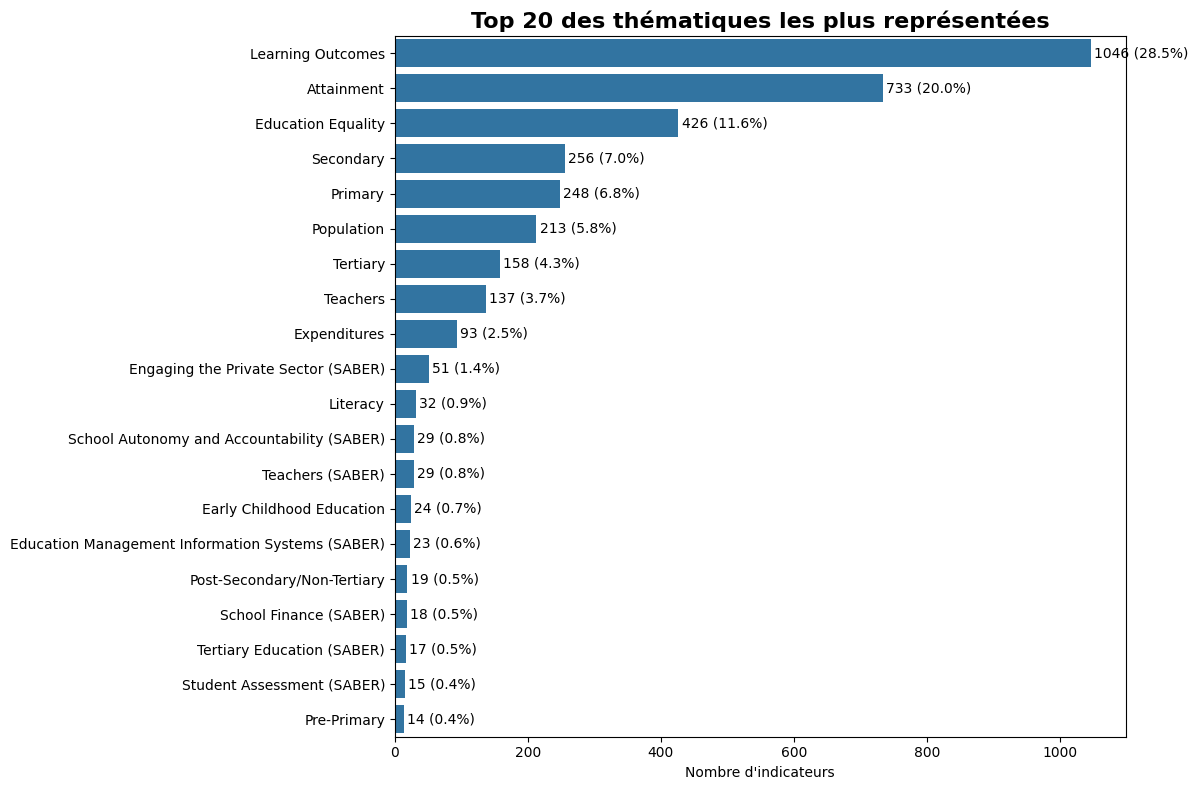

In [164]:
top_topics = (
    dfSeries["topic"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_topics.columns = ["topic", "count"]

total = dfSeries["topic"].value_counts().sum()
top_topics["percent"] = (
    top_topics["count"] / total * 100
).round(1)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=top_topics,
    x="count",
    y="topic"
)

plt.title(
    "Top 20 des thématiques les plus représentées",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Nombre d'indicateurs")
plt.ylabel("")

for i, row in top_topics.iterrows():
    ax.text(
        row["count"] + 5,
        i,
        f'{row["count"]} ({row["percent"]}%)',
        va="center"
    )

plt.tight_layout()
plt.show()

In [165]:
# Parmi les 37 catégories disponibles, nous avons retenu 16 catégories qui font sens par rapport à l'expansion internationale, le business de la formation en ligne pour un public de niveau lycée et université. 

df_topic_selection = pd.DataFrame({
    "Topic": [
        "Learning Outcomes",
        "Attainment",
        "Secondary",
        "Population",
        "Tertiary",
        "Education Equality",
        "Literacy",
        "Workforce Development (SABER)",
        "Economic Policy & Debt: Purchasing power parity",
        "Health: Population: Structure",
        "Social Protection & Labor: Labor force structure",
        "Tertiary Education (SABER)",
        "Labor",
        "Infrastructure: Communications",
        "Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita",
        "Health: Population: Dynamics"
    ],
    "Justification_metier": 
[
    "Qualité du système éducatif et niveau académique.",
    "Niveau d’éducation et accès au supérieur.",
    "Public cible potentiel.",
    "Potentiel du marché EdTech.",
    "Marché du supérieur et concurrence.",
    "Inclusion éducative et barrières d’accès.",
    "Niveau d’éducation de base.",
    "Marché du travail et compétences.",
    "Pouvoir d’achat pour l’éducation.",
    "Structure démographique du marché.",
    "Besoins en formation et upskilling.",
    "Insights stratégiques supérieur.",
    "Demande en qualifications pro.",
    "Accès numérique et EdTech.",
    "Capacité d’investissement éducatif.",
    "Croissance du public cible."
    ]
})

pd.set_option("display.max_colwidth", None)

display(df_topic_selection)

,Topic,Justification_metier
0,Learning Outcomes,Qualité du système éducatif et niveau académique.
1,Attainment,Niveau d’éducation et accès au supérieur.
2,Secondary,Public cible potentiel.
3,Population,Potentiel du marché EdTech.
4,Tertiary,Marché du supérieur et concurrence.
5,Education Equality,Inclusion éducative et barrières d’accès.
6,Literacy,Niveau d’éducation de base.
7,Workforce Development (SABER),Marché du travail et compétences.
8,Economic Policy & Debt: Purchasing power parity,Pouvoir d’achat pour l’éducation.
9,Health: Population: Structure,Structure démographique du marché.


In [166]:
# Visualisation des indicateurs choisis avec la somme des lignes par thème, le pourcentage du total et le pourcentage cumulé.
topics_selected = [
    "Learning Outcomes",
    "Attainment",
    "Secondary",
    "Population",
    "Tertiary",
    "Education Equality",
    "Literacy",
    "Workforce Development (SABER)",
    "Economic Policy & Debt: Purchasing power parity",
    "Health: Population: Structure",
    "Social Protection & Labor: Labor force structure",
    "Tertiary Education (SABER)",
    "Labor",
    "Infrastructure: Communications",
    "Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita",
    "Health: Population: Dynamics"
]

df_topic_analysis_selected = df_topic_analysis.loc[
    df_topic_analysis.index.isin(topics_selected)
]

justifications = {
    "Learning Outcomes": "Qualité du système éducatif et niveau académique.",
    "Attainment": "Niveau d’éducation et accès au supérieur.",
    "Secondary": "Public cible potentiel.",
    "Population": "Potentiel du marché EdTech.",
    "Tertiary": "Marché du supérieur et concurrence.",
    "Education Equality": "Inclusion éducative et barrières d’accès.",
    "Literacy": "Niveau d’éducation de base.",
    "Workforce Development (SABER)": "Marché du travail et compétences.",
    "Economic Policy & Debt: Purchasing power parity": "Pouvoir d’achat pour l’éducation.",
    "Health: Population: Structure": "Structure démographique du marché.",
    "Social Protection & Labor: Labor force structure": "Besoins en formation et upskilling.",
    "Tertiary Education (SABER)": "Insights stratégiques supérieur.",
    "Labor": "Demande en qualifications pro.",
    "Infrastructure: Communications": "Accès numérique et EdTech.",
    "Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita": "Capacité d’investissement éducatif.",
    "Health: Population: Dynamics": "Croissance du public cible."
}

df_topic_analysis_selected["Justification_metier"] = (
    df_topic_analysis_selected.index.map(justifications)
)

display(df_topic_analysis_selected)

print(
    "Pourcentage cumulé couvert par les catégories sélectionnées :",
    round(df_topic_analysis_selected["percent"].sum(), 1),
    "%"
)

,count,percent,cumulative_percent,Justification_metier
topic,,,,
Learning Outcomes,1046,29.00,29.00,Qualité du système éducatif et niveau académique.
Attainment,733,20.00,49.00,Niveau d’éducation et accès au supérieur.
Education Equality,426,12.00,60.00,Inclusion éducative et barrières d’accès.
Secondary,256,7.00,67.00,Public cible potentiel.
Population,213,6.00,80.00,Potentiel du marché EdTech.
Tertiary,158,4.00,84.00,Marché du supérieur et concurrence.
Literacy,32,1.00,93.00,Niveau d’éducation de base.
Tertiary Education (SABER),17,0.00,97.00,Insights stratégiques supérieur.
Health: Population: Structure,13,0.00,98.00,Structure démographique du marché.


Pourcentage cumulé couvert par les catégories sélectionnées : 79.0 %


#### **Calcul du nombre d’indicateurs restants.**

In [167]:
# Création de la liste des catégories métier retenues.

topics_selected = [
    "Learning Outcomes",
    "Attainment",
    "Secondary",
    "Population",
    "Tertiary",
    "Education Equality",
    "Literacy",
    "Workforce Development (SABER)",
    "Economic Policy & Debt: Purchasing power parity",
    "Health: Population: Structure",
    "Social Protection & Labor: Labor force structure",
    "Tertiary Education (SABER)",
    "Labor",
    "Infrastructure: Communications",
    "Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita",
    "Health: Population: Dynamics"
]

# Filtrage de la base "dfSeries" avec les catégories sélectionnées

dfSeries_selected = dfSeries[
    dfSeries["topic"].isin(topics_selected)
]

# Calcul du nombre d'indicateurs conservés après la sélection métier

print(
    "Nombre d'indicateurs retenus :",
    dfSeries_selected["indicator_name"].nunique()
)

# Création de la liste des indicateurs sélectionnés

selected_indicators = dfSeries_selected[
    "series_code"
].unique()

# Filtrage de la base "dfData_clean" pour ne conserver
# que les indicateurs retenus

dfData_selected = dfData_clean[
    dfData_clean["indicator_code"].isin(selected_indicators)
]

print("Dimensions de dfData_selected :", dfData_selected.shape)

Nombre d'indicateurs retenus : 2927
Dimensions de dfData_selected : (625752, 51)


#### **Justification métier des catégories retenues**

Parmi les 37 catégories disponibles, nous avons retenu 16 catégories qui font sens par rapport à l'expansion internationale, le business de la formation en ligne pour un public de niveau lycée et université.
La sélection métier a permis de réduire le périmètre d'analyse de 3 665 à 2 927 indicateurs, soit une réduction d'environ 20 %.

Les catégories retenues permettent notamment d’analyser :
- la taille et le potentiel des marchés éducatifs ;
- le niveau d’éducation et la qualité des systèmes éducatifs ;
- le potentiel d’accès à l’enseignement supérieur ;
- les conditions socio-économiques favorables à la consommation de services éducatifs ;
- les besoins en formation, en employabilité et en développement des compétences ;
- les facteurs démographiques pouvant influencer la demande future.

Les autres catégories ont été exclues car elles présentent un lien moins direct avec l'identification des marchés prioritaires pour une entreprise EdTech.

In [168]:
# Vérification de la réduction du périmètre d'analyse

nb_avant = dfSeries["indicator_name"].nunique()
nb_apres = dfSeries_selected["indicator_name"].nunique()

print("Nombre d'indicateurs avant filtrage :", nb_avant)
print("Nombre d'indicateurs après filtrage :", nb_apres)
print(
    "Indicateurs exclus :",
    nb_avant - nb_apres
)
print(
    "Réduction du périmètre :",
    round((nb_avant - nb_apres) / nb_avant * 100, 1),
    "%"
)

Nombre d'indicateurs avant filtrage : 3665
Nombre d'indicateurs après filtrage : 2927
Indicateurs exclus : 738
Réduction du périmètre : 20.1 %


### **Étape 2 - Réduisez le périmetre en utilisant une approche data**

Objectifs :
- Sélectionner les indicateurs utiles.
- Choisir les années pertinentes.
- Construire un jeu de données fiable.

#### **Proportion de valeurs renseignées par année et par indicateur.**
- Les colonnes numériques représentent les années de mesure des indicateurs.
- Nous allons filtrer, les années a fin de obtenir les meilleures informations pour un projet d’expansion à l’international.

In [169]:
# Visualisation des colonnes TT "dfData".

dfData_clean.shape

(791640, 51)

In [170]:
# Visualisation des colonnes sur la base "dfData".

dfData_clean.columns

Index(['country_name', 'country_code', 'indicator_name', 'indicator_code',
       '1970', '1975', '1980', '1985', '1990', '1991', '1992', '1993', '1994',
       '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2020', '2025', '2030', '2035', '2040', '2045',
       '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090',
       '2095', '2100'],
      dtype='str')

In [171]:
# Identification des années dans toutes les colonnes de la base "dfData_selected".

years = [col for col in dfData_selected.columns if col.isdigit()]

print(years)

['1970', '1975', '1980', '1985', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2020', '2025', '2030', '2035', '2040', '2045', '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100']


In [172]:
# Colonnes années
year_cols = [col for col in dfData.columns if str(col).isdigit()]

# Nombre de valeurs disponibles par année
indicators_count_by_year = dfData[year_cols].notna().sum()

indicators_count_by_year.head()

1970     72288
1975     87306
1980     89122
1985     90296
1990    124405
dtype: int64

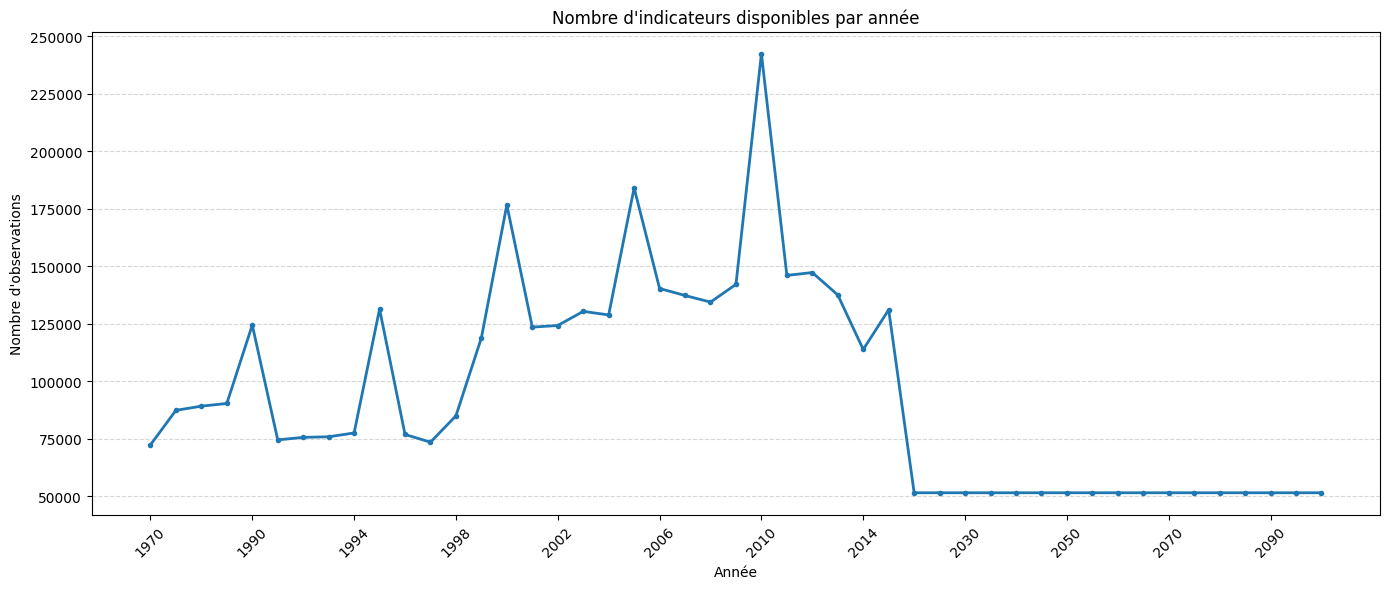

In [173]:
# Colonnes années
year_cols = [col for col in dfData.columns if str(col).isdigit()]

# Nombre d'indicateurs renseignés par année
indicators_count_by_year = dfData[year_cols].notna().sum()

plt.figure(figsize=(14,6))

plt.plot(
    indicators_count_by_year.index,
    indicators_count_by_year.values,
    linewidth=2,
    marker="o",
    markersize=3
)

plt.xticks(
    indicators_count_by_year.index[::4],
    rotation=45
)

plt.title("Nombre d'indicateurs disponibles par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'observations")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

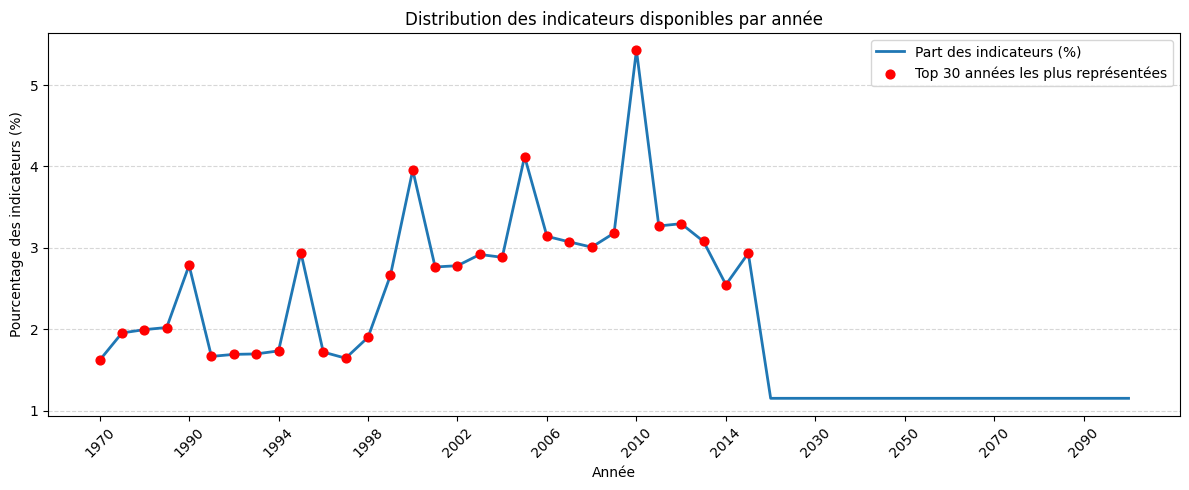

In [174]:
# Visualisation de la distribution des indicateurs remplis par année

pct_indicators_by_year = (
    indicators_count_by_year / indicators_count_by_year.sum() * 100
)

top30 = pct_indicators_by_year.nlargest(30)

plt.figure(figsize=(12,5))

# Courbe principale
plt.plot(
    pct_indicators_by_year.index,
    pct_indicators_by_year.values,
    linewidth=2,
    label="Part des indicateurs (%)"
)

# Top 30 années
plt.scatter(
    top30.index,
    top30.values,
    color="red",
    s=40,
    zorder=3,
    label="Top 30 années les plus représentées"
)

# Une année sur 4
plt.xticks(
    pct_indicators_by_year.index[::4],
    rotation=45
)

plt.title("Distribution des indicateurs disponibles par année")
plt.xlabel("Année")
plt.ylabel("Pourcentage des indicateurs (%)")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [246]:
# Nombre d'indicateurs disponibles par année

ranking_years = (
    indicators_count_by_year
    .sort_values(ascending=False)
    .reset_index()
)

ranking_years.columns = [
    "Année",
    "Nombre d'indicateurs"
]

ranking_years["Rang"] = (
    ranking_years.index + 1
)

ranking_years = ranking_years[
    ["Rang", "Année", "Nombre d'indicateurs"]
]

display(ranking_years.head(30))

,Rang,Année,Nombre d'indicateurs
0,1,2010,242442
1,2,2005,184108
2,3,2000,176676
3,4,2012,147264
4,5,2011,146012
5,6,2009,142108
6,7,2006,140312
7,8,2013,137509
8,9,2007,137272
9,10,2008,134387


In [175]:
all_years = pd.DataFrame({
    "Year": indicators_count_by_year.index,
    "Contribution_Pct": pct_indicators_by_year.values
})

In [176]:
# Calcul du pourcentage d'indicateurs disponibles entre 1990 et 2015

pct_1990_2015 = (
    all_years[
        (all_years['Year'].astype(int) >= 1990) &
        (all_years['Year'].astype(int) <= 2015)
    ]['Contribution_Pct']
    .sum()
)

print(
    f"La période 1990–2015 représente {pct_1990_2015:.1f}% "
    "du volume total d'indicateurs renseignés."
)

La période 1990–2015 représente 72.8% du volume total d'indicateurs renseignés.


#### **Justification Data - Années**

- La période 1990–2015 représente la plus majorité des années avec des distribuition des indicateurs (66.7% du volume total d'indicateurs renseignés).
- Aprés 2026 les données indiquent des projections futures lesquels ne sont pas necessaires sur l'objeticf du projet.
- La plus grand concentration des indicateurs est en 2010 (5.5%)
- Pour les analyses du projet la période 1990–2015 constitue donc l'intervalle le plus pertinent et le plus robuste en termes de disponibilité des données.

In [177]:
# Construction de la liste des années retenues

annees_selectionnees = np.arange(1990, 2016)

print(annees_selectionnees)

[1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015]


In [178]:
annees_selectionnees = np.arange(1990, 2016).astype(str)

colonnes_finales = [
    "country_name",
    "country_code",
    "indicator_name",
    "indicator_code"
] + list(annees_selectionnees)

dfData_filtered = dfData_selected[colonnes_finales]

dfData_filtered.shape

(625752, 30)

In [179]:
rows_before, cols_before = dfData_selected.shape
rows_after, cols_after = dfData_filtered.shape

print(f"Avant filtrage : {rows_before} lignes, {cols_before} colonnes")
print(f"Après filtrage : {rows_after} lignes, {cols_after} colonnes")

print(f"Colonnes supprimées : {cols_before - cols_after}")
print(f"Réduction des colonnes : {((cols_before - cols_after) / cols_before) * 100:.1f}%")

Avant filtrage : 625752 lignes, 51 colonnes
Après filtrage : 625752 lignes, 30 colonnes
Colonnes supprimées : 21
Réduction des colonnes : 41.2%


#### **Analyse des Indicateurs avec la plus grand quantité des données disponibles**
- Les indicateurs les plus complets concernent principalement la durée théorique des cycles d'enseignement et l'âge officiel d'entrée dans les différents niveaux scolaires.
- Les indicateurs les plus renseignés comptabilisent plus de 5 000 valeurs disponibles sur la période 1990–2015.
- Ces résultats confirment que les indicateurs structurels des systèmes éducatifs sont les mieux couverts dans la base de données.

In [180]:
# Visualisation des colonnes sur la base "dfData_filtered"

years_analysis = [str(y) for y in range(1990, 2016)]

In [181]:
# Identification de la complétude des indicateurs

indicator = (
    dfData_selected
    .groupby("indicator_name")[years_analysis]
    .count()
    .sum(axis=1)
    .sort_values(ascending=False)
)

In [182]:
# Calcul du nombre de valeurs renseignées et du taux de remplissage

total_possible = (
    dfData_selected["country_code"].nunique()
    * len(years_analysis)
)

indicator_completeness = (
    dfData_selected
    .groupby("indicator_name")[years_analysis]
    .count()
    .sum(axis=1)
    .reset_index(name="nb_values")
)

# Taux de remplissage (%)

indicator_completeness["taux_remplissage"] = (
    indicator_completeness["nb_values"]
    / total_possible
    * 100
).round(1)

# Complétude relative (%)

indicator_completeness["indicator_completeness"] = (
    indicator_completeness["nb_values"]
    / indicator_completeness["nb_values"].max()
    * 100
).round(1)

indicator_completeness = indicator_completeness.sort_values(
    "taux_remplissage",
    ascending=False
)

display(indicator_completeness.head(50))

,indicator_name,nb_values,taux_remplissage,indicator_completeness
2084,"Population, total",5559,99.00,100.00
1858,Population growth (annual %),5553,98.90,99.90
1335,Official entrance age to lower secondary education (years),5298,94.30,95.30
2333,Theoretical duration of upper secondary education (years),5298,94.30,95.30
2332,Theoretical duration of secondary education (years),5260,93.70,94.60
2034,"Population, ages 15-64 (% of total)",5040,89.70,90.70
2081,"Population, female (% of total)",5036,89.70,90.60
1970,"Population, ages 0-14 (% of total)",5036,89.70,90.60
2083,"Population, male (% of total)",5036,89.70,90.60
1972,"Population, ages 0-14, male",5025,89.50,90.40


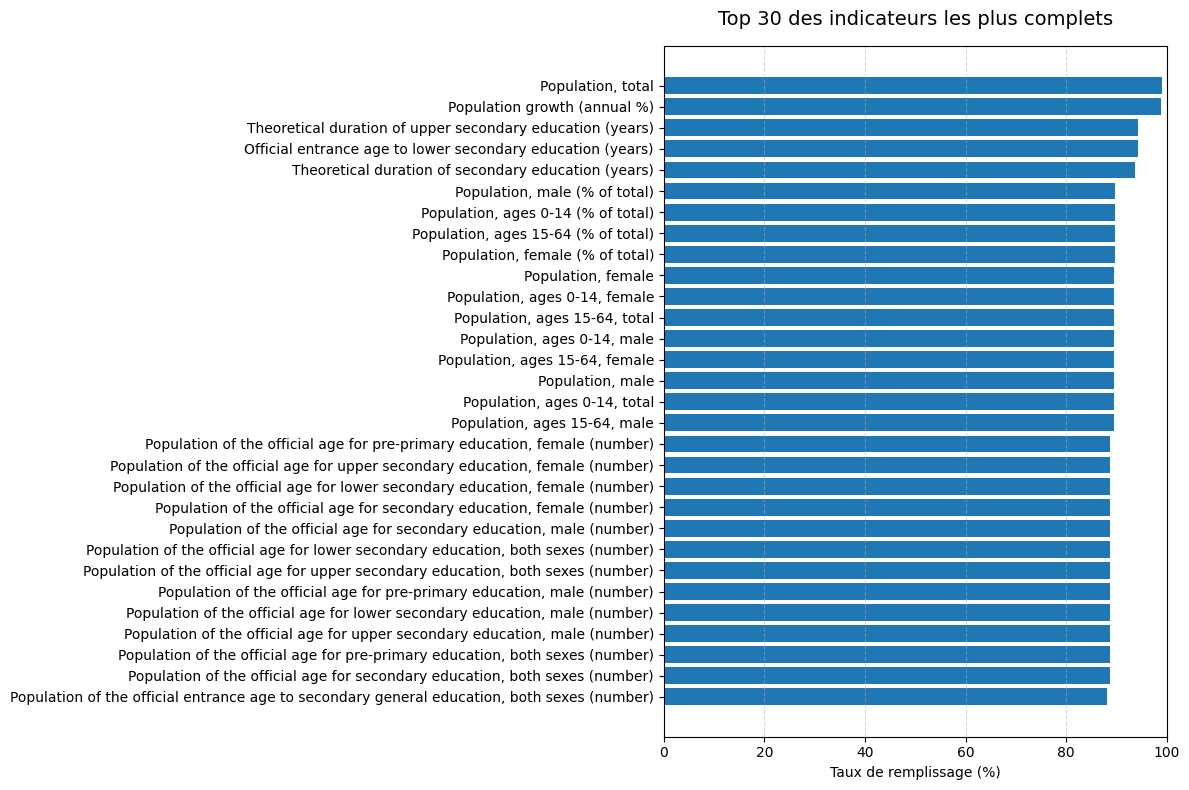

In [183]:
# Top 30 des indicateurs les plus complets

top30_indicators = (
    indicator_completeness
    .sort_values("taux_remplissage", ascending=False)
    .head(30)
    .sort_values("taux_remplissage")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top30_indicators["indicator_name"],
    top30_indicators["taux_remplissage"]
)

plt.title(
    "Top 30 des indicateurs les plus complets",
    fontsize=14,
    pad=15
)

plt.xlabel("Taux de remplissage (%)")

plt.xlim(0, 100)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

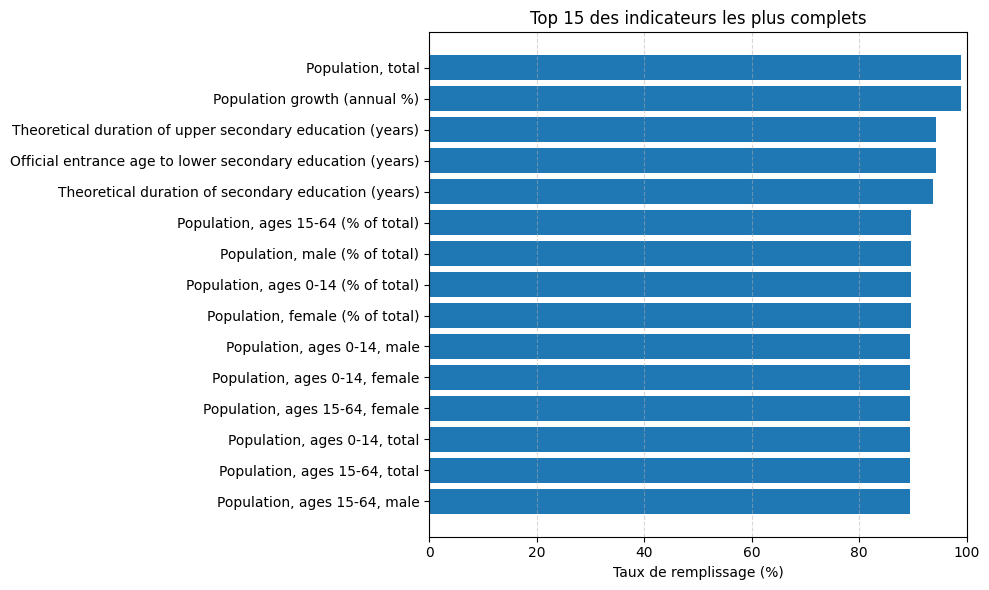

In [184]:
# Visualisation des 15 indicateurs les plus complets
top15 = (
    indicator_completeness
    .sort_values("taux_remplissage", ascending=False)
    .head(15)
    .sort_values("taux_remplissage")
)

plt.figure(figsize=(10,6))

plt.barh(
    top15["indicator_name"],
    top15["taux_remplissage"]
)

plt.title("Top 15 des indicateurs les plus complets")
plt.xlabel("Taux de remplissage (%)")
plt.xlim(0, 100)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

In [185]:
# Identification du nombre de pays renseignés par indicateur et par année

indicator_year = (
    dfData_selected
    .melt(
        id_vars=[
            "country_name",
            "country_code",
            "indicator_name",
            "indicator_code"
        ],
        value_vars=years_analysis,
        var_name="year",
        value_name="value"
    )
    .dropna(subset=["value"])
    .groupby(
        ["indicator_name", "year"]
    )["country_code"]
    .nunique()
    .reset_index(name="nb_countries")
)

display(indicator_year.head())

,indicator_name,year,nb_countries
0,"Adjusted net enrolment rate, lower secondary, both sexes (%)",1990,21
1,"Adjusted net enrolment rate, lower secondary, both sexes (%)",1991,26
2,"Adjusted net enrolment rate, lower secondary, both sexes (%)",1992,30
3,"Adjusted net enrolment rate, lower secondary, both sexes (%)",1993,32
4,"Adjusted net enrolment rate, lower secondary, both sexes (%)",1994,39


In [186]:
#Trier pour obtenir les indicateurs les plus riches qui sont majoritairement liées à population, santé, économie et éducation.

indicator_ranking = (
    indicator_year
    .groupby("indicator_name")["nb_countries"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

indicator_ranking.columns = [
    "indicator_name",
    "avg_nb_countries"
]

display(indicator_ranking.head(30))

,indicator_name,avg_nb_countries
0,"Population, total",213.81
1,Population growth (annual %),213.58
2,Theoretical duration of upper secondary education (years),203.77
3,Official entrance age to lower secondary education (years),203.77
4,Theoretical duration of secondary education (years),202.31
5,"Population, ages 15-64 (% of total)",193.85
6,"Population, male (% of total)",193.69
7,"Population, ages 0-14 (% of total)",193.69
8,"Population, female (% of total)",193.69
9,"Population, ages 0-14, male",193.27


In [187]:
dfTopIndicators = indicator_ranking.head(30)

In [188]:
# Liste de indicateurs clés pour l'analyse métier, en excluant les indicateurs liés à la population et sex () qui sont moins pertinents pour l'analyse de marché et de l'environnement concurrentiel dans le secteur de l'éducation en ligne.

indicator_ranking_metier = indicator_ranking[
    ~indicator_ranking["indicator_name"]
    .str.contains(
        "Population|Male|Female|Gender",
        case=False,
        na=False
    )
]

display(indicator_ranking_metier.head(60))


,indicator_name,avg_nb_countries
2,Theoretical duration of upper secondary education (years),203.77
3,Official entrance age to lower secondary education (years),203.77
4,Theoretical duration of secondary education (years),202.31
45,"Labor force, total",185.73
226,"GDP, PPP (constant 2011 international $)",183.38
227,"GDP per capita, PPP (constant 2011 international $)",183.27
228,"GDP, PPP (current international $)",183.19
229,"GDP per capita, PPP (current international $)",183.08
230,"GNI per capita, Atlas method (current US$)",181.00
231,"Gross outbound enrolment ratio, all regions, both sexes (%)",179.06


#### **Justification Data - TOP 15 indicateurs**
Parmi les indicateurs les plus complets en données, nous avons retenu quinze indicateurs présentant à la fois un fort niveau de couverture et une pertinence métier pour l'expansion internationale d'Academy.

In [189]:
# Sélection des 15 indicateurs les plus pertinents d'un point de vue métier
# parmi les indicateurs les plus complets en données.

selected_indicators = [

    # Structure du système éducatif
    "Theoretical duration of upper secondary education (years)",
    "Official entrance age to lower secondary education (years)",
    "Theoretical duration of secondary education (years)",

    # Marché de l'enseignement supérieur
    "Gross outbound enrolment ratio, all regions, both sexes (%)",

    # Maturité numérique
    "Internet users (per 100 people)",

    # Pouvoir d'achat
    "GDP per capita, PPP (constant 2011 international $)",
    "GNI per capita, Atlas method (current US$)",

    # Marché du travail
    "Labor force, total",

    # Niveau d'éducation moyen (Wittgenstein)
    "Wittgenstein Projection: Mean years of schooling. Age 25+. Total",
    "Wittgenstein Projection: Mean years of schooling. Age 20-39. Total",
    "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total",

    # Taille du vivier d'étudiants
    "Enrolment in lower secondary general, both sexes (number)",
    "Enrolment in upper secondary general, both sexes (number)",
    "Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)",

    # Niveau d'enseignement supérieur atteint
    "Barro-Lee: Average years of tertiary schooling, age 25+, total"
]

# Filtrage du dataset

dfData_selected = dfData_selected[
    dfData_selected["indicator_name"].isin(selected_indicators)
]

print(
    "Nombre d'indicateurs retenus :",
    dfData_selected["indicator_name"].nunique()
)

Nombre d'indicateurs retenus : 15


In [190]:
# Justification synthétique des indicateurs sélectionnés

justifications = {

    "Theoretical duration of upper secondary education (years)":
        "Structure éducative",

    "Official entrance age to lower secondary education (years)":
        "Organisation scolaire",

    "Theoretical duration of secondary education (years)":
        "Parcours scolaire",

    "Gross outbound enrolment ratio, all regions, both sexes (%)":
        "Mobilité étudiante",

    "Internet users (per 100 people)":
        "Accessibilité numérique",

    "GDP per capita, PPP (constant 2011 international $)":
        "Pouvoir d'achat",

    "GNI per capita, Atlas method (current US$)":
        "Niveau de revenu",

    "Labor force, total":
        "Potentiel économique",

    "Wittgenstein Projection: Mean years of schooling. Age 25+. Total":
        "Niveau d'éducation",

    "Wittgenstein Projection: Mean years of schooling. Age 20-39. Total":
        "Population active qualifiée",

    "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total":
        "Futurs étudiants",

    "Enrolment in lower secondary general, both sexes (number)":
        "Vivier d'élèves",

    "Enrolment in upper secondary general, both sexes (number)":
        "Marché cible",

    "Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)":
        "Orientation académique",

    "Barro-Lee: Average years of tertiary schooling, age 25+, total":
        "Capital humain"
}

# Sélection des indicateurs retenus

df_selected_indicators = (
    indicator_ranking[
        indicator_ranking["indicator_name"].isin(selected_indicators)
    ][["indicator_name", "avg_nb_countries"]]
    .copy()
)

# Ajout de la justification métier

df_selected_indicators["justification"] = (
    df_selected_indicators["indicator_name"]
    .map(justifications)
)

# Mise en forme

df_selected_indicators = (
    df_selected_indicators
    .rename(columns={
        "indicator_name": "Indicateur",
        "avg_nb_countries": "Pays couverts",
        "justification": "Justification"
    })
    .sort_values(
        by="Pays couverts",
        ascending=False
    )
)

display(df_selected_indicators)

,Indicateur,Pays couverts,Justification
2,Theoretical duration of upper secondary education (years),203.77,Structure éducative
3,Official entrance age to lower secondary education (years),203.77,Organisation scolaire
4,Theoretical duration of secondary education (years),202.31,Parcours scolaire
45,"Labor force, total",185.73,Potentiel économique
227,"GDP per capita, PPP (constant 2011 international $)",183.27,Pouvoir d'achat
230,"GNI per capita, Atlas method (current US$)",181.00,Niveau de revenu
231,"Gross outbound enrolment ratio, all regions, both sexes (%)",179.06,Mobilité étudiante
234,Internet users (per 100 people),173.77,Accessibilité numérique
256,Wittgenstein Projection: Mean years of schooling. Age 20-39. Total,166.00,Population active qualifiée
262,Wittgenstein Projection: Mean years of schooling. Age 15-19. Total,166.00,Futurs étudiants


#### **Justification Data & Métier – Sélection des 15 indicateurs**

Les indicateurs ont été sélectionnés selon deux critères complémentaires :

- leur niveau de complétude dans les données (nombre moyen de pays renseignés) ;
- leur pertinence métier pour évaluer le potentiel d’expansion internationale d’Academy.

L’objectif est de conserver des indicateurs à la fois exploitables d’un point de vue statistique et représentatifs des dimensions clés du marché : qualité du système éducatif, accès à l’enseignement supérieur, maturité numérique, capacité financière et potentiel du marché du travail.

In [191]:
# Nombre total d'indicateurs disponibles dans la base

before = dfSeries["indicator_name"].nunique()

# Nombre d'indicateurs retenus pour l'analyse

after = len(selected_indicators)

reduction = (1 - after / before) * 100

print(f"Indicateurs avant sélection : {before}")
print(f"Indicateurs retenus : {after}")
print(f"Réduction : {reduction:.1f}%")

Indicateurs avant sélection : 3665
Indicateurs retenus : 15
Réduction : 99.6%


In [192]:
dfData_selected["indicator_name"].nunique()

15

### **Étape 3 - Consolidez vos résultas dans un dataframe (pays, indicateurs)**

#### **Construction du dataset final**

In [193]:
# Construction du dataset final avec les années de 1990 à 2015 pour l'analyse et la visualisation des données.

years_final = [str(y) for y in range(1990, 2016)]

cols_final = [
    "country_name",
    "country_code",
    "indicator_name",
    "indicator_code"
] + years_final

dfFinal = dfData_selected[
    dfData_selected["indicator_name"].isin(selected_indicators)
][cols_final]

dfFinal.shape

(3240, 30)

In [194]:
#visualisation des colonnes du dataset final

dfFinal.columns

Index(['country_name', 'country_code', 'indicator_name', 'indicator_code',
       '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998',
       '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015'],
      dtype='str')

In [195]:
# visualisation du nombre d'indicateurs uniques
dfFinal["indicator_name"].nunique()

15

In [196]:
# visualisation de la quantité de pays uniques
dfFinal["country_code"].nunique()

216

In [197]:
#visualisation des 10 indicateurs les plus renseignés dans la base de données

dfFinal.isna().sum().sort_values(ascending=False).head(20)

1991    2098
1992    2072
1993    2050
1994    2022
1996    1925
1997    1901
1995    1816
1990    1788
1998    1604
2014    1476
2015    1353
2013    1280
2012    1232
1999    1222
2003    1212
2011    1208
2006    1205
2001    1192
2002    1178
2004    1178
dtype: int64

In [198]:
# transformation du dataset final pour l'analyse et la visualisation des données.

dfFinal_complet = dfFinal.melt(
    id_vars=[
        "country_name",
        "country_code",
        "indicator_name",
        "indicator_code"
    ],
    var_name="year",
    value_name="value"

)

In [199]:
# visualisation des colonnes du dataset final transformé

indicator_year_final = (
    dfFinal_complet
    .dropna(subset=["value"])
    .groupby(
        ["indicator_name", "year"]
    )["country_code"]
    .nunique()
    .reset_index(name="nb_countries")
)

indicator_year_final.head(20)

,indicator_name,year,nb_countries
0,"Barro-Lee: Average years of tertiary schooling, age 25+, total",1990,144
1,"Barro-Lee: Average years of tertiary schooling, age 25+, total",1995,144
2,"Barro-Lee: Average years of tertiary schooling, age 25+, total",2000,144
3,"Barro-Lee: Average years of tertiary schooling, age 25+, total",2005,144
4,"Barro-Lee: Average years of tertiary schooling, age 25+, total",2010,144
5,"Enrolment in lower secondary general, both sexes (number)",1999,158
6,"Enrolment in lower secondary general, both sexes (number)",2000,162
7,"Enrolment in lower secondary general, both sexes (number)",2001,168
8,"Enrolment in lower secondary general, both sexes (number)",2002,169
9,"Enrolment in lower secondary general, both sexes (number)",2003,158


In [200]:
'dfFinal' in globals()

True

In [201]:
#Vérification de la complétude des séries temporelles des indicateurs sélectionnés pour la période 1990-2015.

dfFinal[years_final].count(axis=1).describe()

count   3240.00
mean      14.52
std       10.38
min        0.00
25%        2.00
50%       16.00
75%       26.00
max       26.00
dtype: float64

In [202]:
# Création d'une nouvelle colonne "indicator_value" qui représente la moyenne des valeurs des indicateurs pour chaque ligne, en prenant en compte uniquement les années de 1990 à 2015.

dfFinal["indicator_value"] = (
    dfFinal[years_final]
    .mean(axis=1)
)

In [203]:
# Visualisation des 5 premières lignes du dataset final avec la nouvelle colonne "indicator_value" pour vérifier le résultat.
dfFinal[
    [
        "country_name",
        "indicator_name",
        "indicator_value"
    ]
].head()

,country_name,indicator_name,indicator_value
216,Afghanistan,"Barro-Lee: Average years of tertiary schooling, age 25+, total",0.24
1167,Afghanistan,"Enrolment in lower secondary general, both sexes (number)",940479.64
1220,Afghanistan,"Enrolment in upper secondary general, both sexes (number)",446572.00
1246,Afghanistan,"GDP per capita, PPP (constant 2011 international $)",1435.23
1251,Afghanistan,"GNI per capita, Atlas method (current US$)",458.33


In [204]:
# Création du dataset final pour l'analyse et la visualisation des données avec les colonnes essentielles : "country_name", "country_code", "indicator_name", "indicator_code" et "indicator_value".
 
dfModel = dfFinal[
    [
        "country_name",
        "country_code",
        "indicator_name",
        "indicator_code",
        "indicator_value"
    ]
]

In [205]:
dfModel.shape

(3240, 5)

In [206]:
dfModel["indicator_name"].nunique()

15

#### **Conclusion - Dataset final**

- Analyse sur les 216 pays ;
- 15 indicateurs sélectionnés pour leur pertinence métier et leur niveau de complétude ;
- 26 années d'observation (1990–2015).
- Ce jeu de données constitue une base robuste pour les analyses exploratoires avec 3240 lignes et 5 colonnes.
- 15 indicateurs ont été retenus  afin de conserver les indicateurs les plus comparables et les plus riches en données pour les analyses futures (variables structurelles des systèmes éducatifs ainsi que les populations en âge scolaire)


## **Partie 3**
L’analyse des indicateurs sélectionnés a fin de répondre les objectifs principales.

Objectifs :
- Identifier les indicateurs les plus pertinents en analysant les corrélations et en supprimant les variables redondantes.
- Analyser la distribution des indicateurs retenus afin de comprendre les caractéristiques des pays étudiés.
- Construire une méthode quantitative de sélection des pays pour recommander les marchés les plus attractifs pour l’expansion internationale d’Academy.

#### **Étape 1- Identifiez les indicateurs redondants d'un point de vue statistique**

In [207]:
# Visualisation des colonnes du dataset final pour l'analyse et la visualisation des données.

dfFinal["indicator_value"] = (
    dfFinal[years_final]
    .mean(axis=1)
)

dfPivot = dfFinal.pivot_table(
    index="country_name",
    columns="indicator_name",
    values="indicator_value"
)

dfPivot.shape

print(dfPivot.shape)

(215, 15)


In [208]:
# Agregations des donnees des années dans une unique measure par indicateur

dfFinal["indicator_value"] = (
    dfFinal[years_final]
    .mean(axis=1)
)

In [209]:
# Transposition du dataset dans un format adapté aux besoins du projet (wide format)
 
dfPivot = dfFinal.pivot_table(
    index="country_name",
    columns="indicator_name",
    values="indicator_value"
)

print(dfPivot)

indicator_name         Barro-Lee: Average years of tertiary schooling, age 25+, total  \
country_name                                                                            
Afghanistan                                                                      0.24   
Albania                                                                          0.17   
Algeria                                                                          0.21   
American Samoa                                                                    NaN   
Andorra                                                                           NaN   
...                                                                               ...   
Virgin Islands (U.S.)                                                             NaN   
West Bank and Gaza                                                                NaN   
Yemen, Rep.                                                                      0.05   
Zambia               

In [210]:
# vérification des missing values dans le dataset final après la transposition

dfPivot.isna().sum()

indicator_name
Barro-Lee: Average years of tertiary schooling, age 25+, total                                        71
Enrolment in lower secondary general, both sexes (number)                                             13
Enrolment in upper secondary general, both sexes (number)                                             13
GDP per capita, PPP (constant 2011 international $)                                                   23
GNI per capita, Atlas method (current US$)                                                            16
Gross outbound enrolment ratio, all regions, both sexes (%)                                           22
Internet users (per 100 people)                                                                        7
Labor force, total                                                                                    29
Official entrance age to lower secondary education (years)                                             7
Percentage of students in lower secondar

In [211]:
# utilisation de la methode de corrélation de Pearson pour analyser les relations entre les indicateurs dans le dataset final.

corr_pearson = dfPivot.corr(method="pearson")

##### **Méthode de Pearson** 

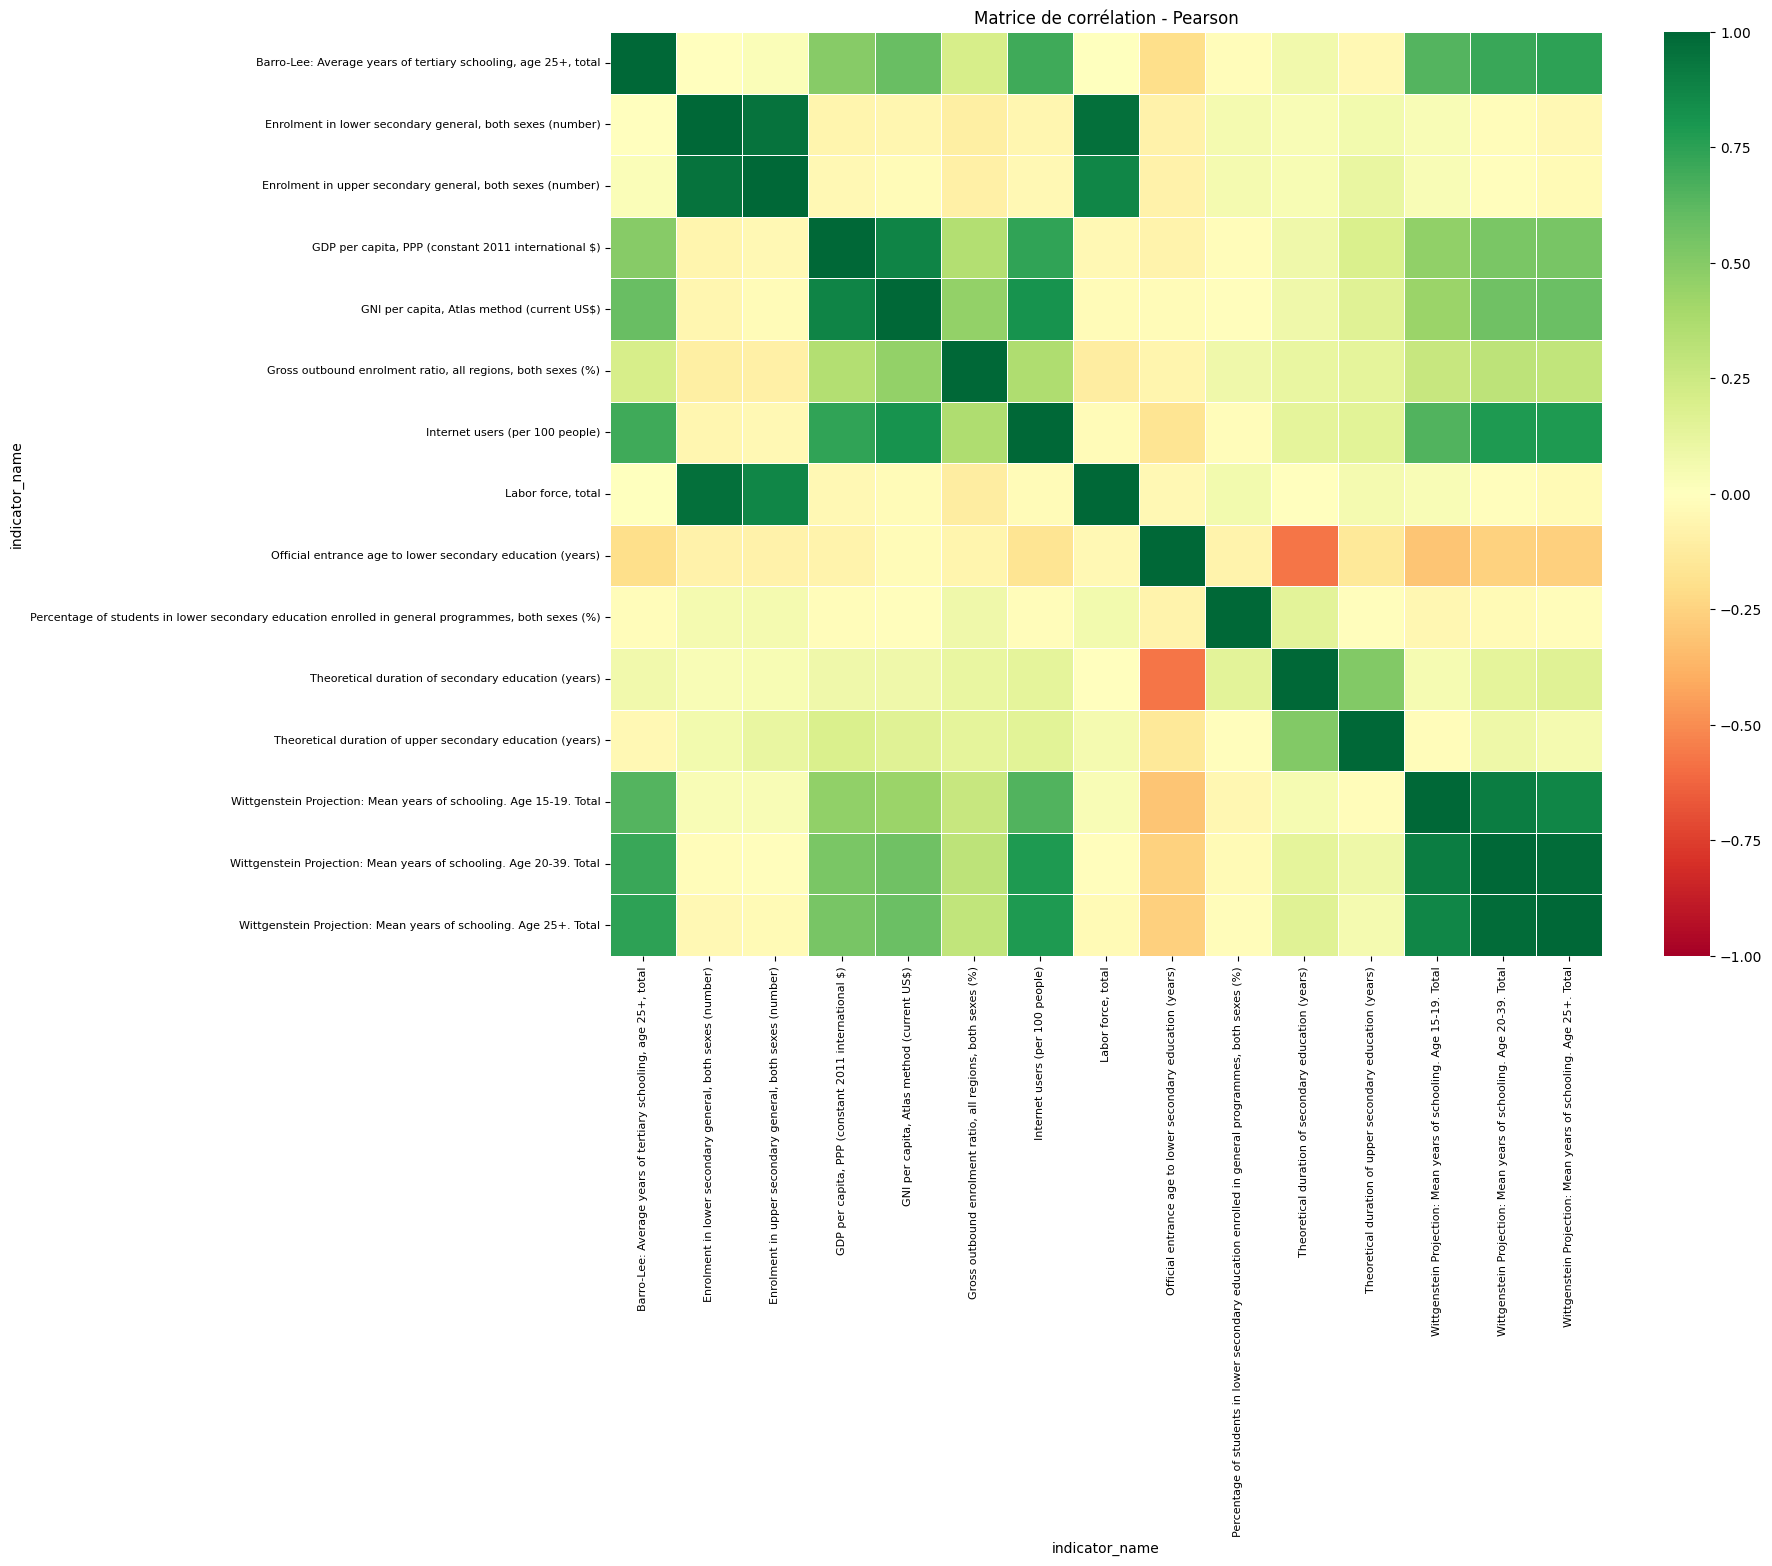

In [212]:

# Construction d'une heatmap pour visualiser les corrélations entre les indicateurs dans le dataset final.

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_pearson,
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Matrice de corrélation - Pearson")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.show()

##### **Méthode de Spearman** 

In [213]:
# utilisation de la methode de corrélation de Spearman pour visualiser les relations entre les indicateurs dans le dataset final.

corr_spearman = dfPivot.corr(method="spearman").abs()

def color_corr(val):
    if 0.70 <= val < 1:
        return "background-color: #b7e1cd"
    return ""

corr_spearman.style.map(color_corr).format("{:.2f}")

indicator_name,"Barro-Lee: Average years of tertiary schooling, age 25+, total","Enrolment in lower secondary general, both sexes (number)","Enrolment in upper secondary general, both sexes (number)","GDP per capita, PPP (constant 2011 international $)","GNI per capita, Atlas method (current US$)","Gross outbound enrolment ratio, all regions, both sexes (%)",Internet users (per 100 people),"Labor force, total",Official entrance age to lower secondary education (years),"Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)",Theoretical duration of secondary education (years),Theoretical duration of upper secondary education (years),Wittgenstein Projection: Mean years of schooling. Age 15-19. Total,Wittgenstein Projection: Mean years of schooling. Age 20-39. Total,Wittgenstein Projection: Mean years of schooling. Age 25+. Total
indicator_name,,,,,,,,,,,,,,,
"Barro-Lee: Average years of tertiary schooling, age 25+, total",1.00,0.07,0.19,0.75,0.75,0.40,0.79,0.06,0.26,0.07,0.11,0.05,0.70,0.81,0.83
"Enrolment in lower secondary general, both sexes (number)",0.07,1.00,0.95,0.08,0.17,0.67,0.15,0.95,0.13,0.10,0.15,0.05,0.01,0.01,0.02
"Enrolment in upper secondary general, both sexes (number)",0.19,0.95,1.00,0.05,0.04,0.59,0.05,0.90,0.12,0.10,0.10,0.15,0.15,0.15,0.11
"GDP per capita, PPP (constant 2011 international $)",0.75,0.08,0.05,1.00,0.97,0.50,0.89,0.04,0.20,0.06,0.02,0.15,0.72,0.80,0.77
"GNI per capita, Atlas method (current US$)",0.75,0.17,0.04,0.97,1.00,0.57,0.91,0.12,0.16,0.08,0.01,0.14,0.71,0.81,0.78
"Gross outbound enrolment ratio, all regions, both sexes (%)",0.40,0.67,0.59,0.50,0.57,1.00,0.56,0.67,0.16,0.05,0.13,0.04,0.47,0.51,0.50
Internet users (per 100 people),0.79,0.15,0.05,0.89,0.91,0.56,1.00,0.09,0.24,0.02,0.08,0.13,0.73,0.85,0.82
"Labor force, total",0.06,0.95,0.90,0.04,0.12,0.67,0.09,1.00,0.07,0.09,0.03,0.14,0.07,0.02,0.05
Official entrance age to lower secondary education (years),0.26,0.13,0.12,0.20,0.16,0.16,0.24,0.07,1.00,0.12,0.57,0.14,0.30,0.25,0.28


##### **Sélection des indicateurs**

Pour choisir entre deux indicateurs très corrélés, gardez le plus pertinent quant à la problématique métier.

- L'analyse des matrices de corrélation de Pearson et de Spearman a mis en évidence plusieurs indicateurs fortement corrélés (|r| > 0,70).
- Les indicateurs les plus pertinents pour l'étude de l'accès à l'éducation ont été conservés.
- Le tableau ci-dessus présente les indicateurs supprimés ainsi que les justifications associées.

In [214]:
# Suppression des indicateurs excessivement corrélés (donc redondants).
decision_corr = pd.DataFrame({
    "Corrélation": [
        0.98,
        0.97,
        0.95,
        0.91,
        0.88,
        0.87,
        0.87,
        0.82,
        0.79,
        0.79,
        0.75,
        0.74,
        0.72
    ],

    "Indicateur A": [
        "Wittgenstein Projection: Mean years of schooling. Age 20-39. Total",
        "Enrolment in lower secondary general, both sexes (number)",
        "Enrolment in lower secondary general, both sexes (number)",
        "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total",
        "GDP per capita, PPP (constant 2011 international $)",
        "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total",
        "Enrolment in upper secondary general, both sexes (number)",
        "GNI per capita, Atlas method (current US$)",
        "Internet users (per 100 people)",
        "Internet users (per 100 people)",
        "Barro-Lee: Average years of tertiary schooling, age 25+, total",
        "GDP per capita, PPP (constant 2011 international $)",
        "Barro-Lee: Average years of tertiary schooling, age 25+, total"
    ],

    "Indicateur B": [
        "Wittgenstein Projection: Mean years of schooling. Age 25+. Total",
        "Labor force, total",
        "Enrolment in upper secondary general, both sexes (number)",
        "Wittgenstein Projection: Mean years of schooling. Age 20-39. Total",
        "GNI per capita, Atlas method (current US$)",
        "Wittgenstein Projection: Mean years of schooling. Age 25+. Total",
        "Labor force, total",
        "Internet users (per 100 people)",
        "Wittgenstein Projection: Mean years of schooling. Age 20-39. Total",
        "Wittgenstein Projection: Mean years of schooling. Age 25+. Total",
        "Wittgenstein Projection: Mean years of schooling. Age 25+. Total",
        "Internet users (per 100 people)",
        "Wittgenstein Projection: Mean years of schooling. Age 20-39. Total"
    ],

    "Indicateur conservé": [
        "A",
        "B",
        "A",
        "Supprimés les deux",
        "A",
        "A",
        "A",
        "A",
        "A",
        "Supprimés les deux",
        "A",
        "Supprimés les deux",
        "Supprimés les deux"
    ],

    "Justification": [
        "Information similaire sur le niveau moyen d'éducation, fournit une vision plus globale du niveau d'instruction de la population adulte.",
        "Plus directement liée à l'accès à l'éducation du public futur d'Academy.",
        "Plus directement liée à l'accès à l'éducation du public futur d'Academy.",
        "Information similaire sur le niveau moyen d'éducation.",
        "Utilisé pour les comparaisons internationales car il tient compte des différences de coût de la vie entre les pays.",
        "Information similaire sur le niveau moyen d'éducation de la population du Lycée, public d'EdTech.",
        "Il mesure directement la taille de la population scolarisée dans l'enseignement secondaire supérieur.",
        "Comprend le pouvoir moyen de la population.",
        "Lié à l'accessibilité des services numériques et constitue un facteur clé pour comprendre le marché d'une offre EdTech en ligne.",
        "-",
        "Il mesure spécifiquement le niveau d'enseignement supérieur de la population adulte.",
        "-",
        "-"
    ]
})

display(
    decision_corr.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('text-align', 'left')]}
    ])
)

,Corrélation,Indicateur A,Indicateur B,Indicateur conservé,Justification
0,0.980000,Wittgenstein Projection: Mean years of schooling. Age 20-39. Total,Wittgenstein Projection: Mean years of schooling. Age 25+. Total,A,"Information similaire sur le niveau moyen d'éducation, fournit une vision plus globale du niveau d'instruction de la population adulte."
1,0.970000,"Enrolment in lower secondary general, both sexes (number)","Labor force, total",B,Plus directement liée à l'accès à l'éducation du public futur d'Academy.
2,0.950000,"Enrolment in lower secondary general, both sexes (number)","Enrolment in upper secondary general, both sexes (number)",A,Plus directement liée à l'accès à l'éducation du public futur d'Academy.
3,0.910000,Wittgenstein Projection: Mean years of schooling. Age 15-19. Total,Wittgenstein Projection: Mean years of schooling. Age 20-39. Total,Supprimés les deux,Information similaire sur le niveau moyen d'éducation.
4,0.880000,"GDP per capita, PPP (constant 2011 international $)","GNI per capita, Atlas method (current US$)",A,Utilisé pour les comparaisons internationales car il tient compte des différences de coût de la vie entre les pays.
5,0.870000,Wittgenstein Projection: Mean years of schooling. Age 15-19. Total,Wittgenstein Projection: Mean years of schooling. Age 25+. Total,A,"Information similaire sur le niveau moyen d'éducation de la population du Lycée, public d'EdTech."
6,0.870000,"Enrolment in upper secondary general, both sexes (number)","Labor force, total",A,Il mesure directement la taille de la population scolarisée dans l'enseignement secondaire supérieur.
7,0.820000,"GNI per capita, Atlas method (current US$)",Internet users (per 100 people),A,Comprend le pouvoir moyen de la population.
8,0.790000,Internet users (per 100 people),Wittgenstein Projection: Mean years of schooling. Age 20-39. Total,A,Lié à l'accessibilité des services numériques et constitue un facteur clé pour comprendre le marché d'une offre EdTech en ligne.
9,0.790000,Internet users (per 100 people),Wittgenstein Projection: Mean years of schooling. Age 25+. Total,Supprimés les deux,-


In [215]:
# résumé de la sélection finale des indicateurs après l'analyse de corrélation et la prise de décision métier.

resume_selection = pd.DataFrame({
    "Indicateur": [
        "Nombre initial d'indicateurs",
        "Indicateurs supprimés",
        "Indicateurs conservés"
    ],
    "Valeur": [
        15,
        7,
        10
    ]
})

display(resume_selection)

,Indicateur,Valeur
0,Nombre initial d'indicateurs,15
1,Indicateurs supprimés,7
2,Indicateurs conservés,10


##### **Interprétation des résultats**

- Après suppression des indicateurs les plus redondants, au total des 15 indicateurs, 10 indicateurs ont été conservés.

In [216]:
# indicateurs retenus après l'analyse de corrélation et la prise de décision métier.

indicateurs_conserves = pd.DataFrame({
    "Indicateur": [
    "GDP per capita, PPP (constant 2011 international $)",
    "Internet users (per 100 people)",
    "Enrolment in upper secondary general, both sexes (number)",
    "Barro-Lee: Average years of tertiary schooling, age 25+, total",
    "Gross outbound enrolment ratio, all regions, both sexes (%)",
    "Official entrance age to lower secondary education (years)",
    "Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)",
    "Theoretical duration of secondary education (years)",
    "Theoretical duration of upper secondary education (years)",
    "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total"
    ],
    
    "Raison": [
        "Pouvoir d'achat",
        "Accessibilité numérique",
        "Taille du public lycée",
        "Culture de l'enseignement supérieur",
        "Intérêt pour les études",
        "Structure du système éducatif",
        "Orientation académique",
        "Structure éducative",
        "Structure éducative",
        "Niveau d'éducation du public cible"
    ]
})

display(
    indicateurs_conserves.style
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
    )

,Indicateur,Raison
0,"GDP per capita, PPP (constant 2011 international $)",Pouvoir d'achat
1,Internet users (per 100 people),Accessibilité numérique
2,"Enrolment in upper secondary general, both sexes (number)",Taille du public lycée
3,"Barro-Lee: Average years of tertiary schooling, age 25+, total",Culture de l'enseignement supérieur
4,"Gross outbound enrolment ratio, all regions, both sexes (%)",Intérêt pour les études
5,Official entrance age to lower secondary education (years),Structure du système éducatif
6,"Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)",Orientation académique
7,Theoretical duration of secondary education (years),Structure éducative
8,Theoretical duration of upper secondary education (years),Structure éducative
9,Wittgenstein Projection: Mean years of schooling. Age 15-19. Total,Niveau d'éducation du public cible


In [217]:
before = 15
after = len(indicateurs_conserves)

print(f"Indicateurs avant analyse de corrélation : {before}")
print(f"Indicateurs conservés : {after}")
print(f"Indicateurs supprimés : {before - after}")
print(f"Réduction : {(1-after/before)*100:.1f}%")

Indicateurs avant analyse de corrélation : 15
Indicateurs conservés : 10
Indicateurs supprimés : 5
Réduction : 33.3%



#### **Étape 2 - Analysez vos indicateurs restants et formulez une liste de pays pertinents pour l'implantation d'Academy**
- Analyser la distribution des indicateurs retenus afin de comprendre les caractéristiques des pays étudiés.

In [218]:
# création du dataset final avec des indicateurs conservés après l'analyse de corrélation et la prise de décision métier.

indicateurs_conserves_list = indicateurs_conserves["Indicateur"].tolist()

dfFinal_corr = dfPivot[indicateurs_conserves_list]

dfFinal_corr.shape

(215, 10)

In [219]:
# vérification des missing values dans le dataset final après la sélection des indicateurs conservés.

dfFinal_corr.isna().sum().sort_values(ascending=False)

indicator_name
Barro-Lee: Average years of tertiary schooling, age 25+, total                                        71
Wittgenstein Projection: Mean years of schooling. Age 15-19. Total                                    49
GDP per capita, PPP (constant 2011 international $)                                                   23
Gross outbound enrolment ratio, all regions, both sexes (%)                                           22
Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)    13
Enrolment in upper secondary general, both sexes (number)                                             13
Theoretical duration of secondary education (years)                                                   11
Internet users (per 100 people)                                                                        7
Official entrance age to lower secondary education (years)                                             7
Theoretical duration of upper secondary 

In [220]:
(dfFinal.isna().sum() / len(dfFinal) * 100).round(1)

country_name       0.00
country_code       0.00
indicator_name     0.00
indicator_code     0.00
1990              55.20
1991              64.80
1992              64.00
1993              63.30
1994              62.40
1995              56.00
1996              59.40
1997              58.70
1998              49.50
1999              37.70
2000              33.00
2001              36.80
2002              36.40
2003              37.40
2004              36.40
2005              31.80
2006              37.20
2007              36.10
2008              36.10
2009              36.10
2010              17.40
2011              37.30
2012              38.00
2013              39.50
2014              45.60
2015              41.80
indicator_value   12.20
dtype: float64

In [221]:
# Visualisation de la matrice de corrélation des indicateurs conservés après l'analyse de corrélation et la prise de décision métier.

indicateurs_conserves_list = [
    "GDP per capita, PPP (constant 2011 international $)",
    "Internet users (per 100 people)",
    "Enrolment in upper secondary general, both sexes (number)",
    "Barro-Lee: Average years of tertiary schooling, age 25+, total",
    "Gross outbound enrolment ratio, all regions, both sexes (%)",
    "Official entrance age to lower secondary education (years)",
    "Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)",
    "Theoretical duration of secondary education (years)",
    "Theoretical duration of upper secondary education (years)",
    "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total"
]

dfFinal = dfPivot[indicateurs_conserves_list]

dfFinal.shape

(215, 10)

##### **Analyse des indicateurs**
- Analyser la distribution des indicateurs retenus afin de comprendre les caractéristiques des pays étudiés.

In [222]:
# Analyse des indicateur sélectionnés a fin de comprendre la distribution des données sur les pays.

indicateur = "Internet users (per 100 people)"

display(
    dfFinal[indicateur].describe()
)

count   208.00
mean     19.63
std      16.31
min       0.00
25%       5.38
50%      16.50
75%      30.22
max      67.16
Name: Internet users (per 100 people), dtype: float64

<Figure size 800x500 with 0 Axes>

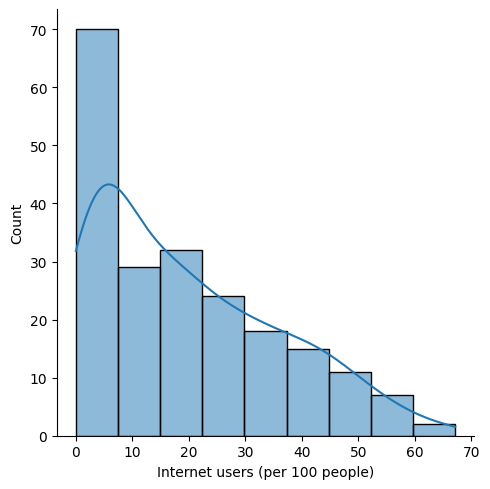

In [223]:
# graphique de distribution de l'indicateur "Internet users (per 100 people)" pour visualiser la répartition des données entre les pays.

plt.figure(figsize=(8,5))

sns.displot(
    data=dfFinal,
    x=indicateur,
    kde=True
)

plt.show()

Les informations des 216 pays pendant les années 1990–2015 nous montrent :
- Une moyenne de 19,63 utilisateurs pour 100 habitants et une médiane de 16,50, ce qui indique qu'une grande partie des pays possède un niveau relativement faible d'accès à Internet. L'écart-type élevé (16,31) montre une forte hétérogénéité entre les pays.
- La majorité des pays sont concentrés sur des niveaux faibles à moyens d'utilisation d'Internet, tandis qu'un nombre plus limité de pays présente des valeurs très élevées.
- Cet indicateur est particulièrement pertinent pour Academy car l'accès à Internet constitue une condition essentielle à l'utilisation d'une offre EdTech en ligne.

##### **Réécrivez le code dans une fonction et appliquez-la à l'ensemble des indicateurs**

In [224]:
# Fonction pour analyser la distribution d'un indicateur sélectionné et visualiser sa répartition entre les pays.

def analyse_indicateur(df, indicateur):

    print(f"\n{'='*80}")
    print(f"Indicateur : {indicateur}")
    print(f"{'='*80}")

    display(df[indicateur].describe())

    sns.displot(
        data=df,
        x=indicateur,
        kde=True
    )

    plt.show()


Indicateur : GDP per capita, PPP (constant 2011 international $)


count      192.00
mean     15884.19
std      19057.61
min        638.00
25%       2973.73
50%       8434.37
75%      19967.91
max     117382.12
Name: GDP per capita, PPP (constant 2011 international $), dtype: float64

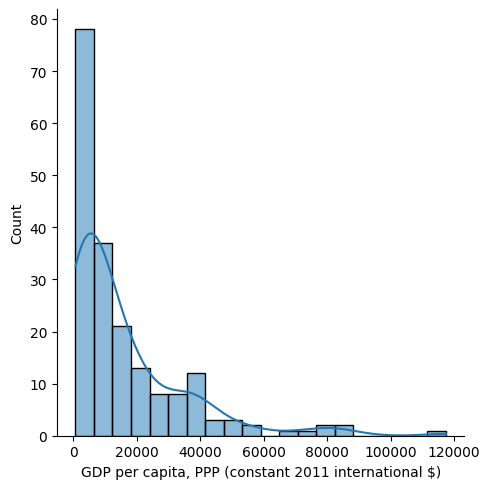


Indicateur : Internet users (per 100 people)


count   208.00
mean     19.63
std      16.31
min       0.00
25%       5.38
50%      16.50
75%      30.22
max      67.16
Name: Internet users (per 100 people), dtype: float64

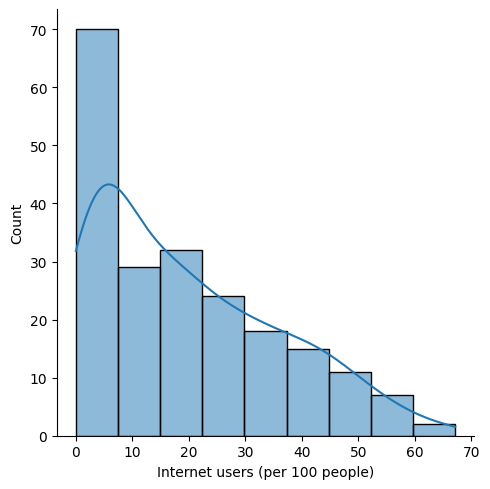


Indicateur : Enrolment in upper secondary general, both sexes (number)


count        202.00
mean      770599.83
std      3136402.92
min          180.40
25%        24204.60
50%       105714.65
75%       421792.12
max     35919252.00
Name: Enrolment in upper secondary general, both sexes (number), dtype: float64

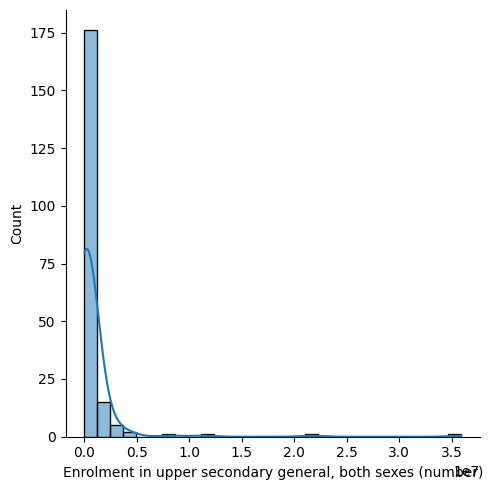


Indicateur : Barro-Lee: Average years of tertiary schooling, age 25+, total


count   144.00
mean      0.37
std       0.31
min       0.01
25%       0.13
50%       0.33
75%       0.55
max       1.56
Name: Barro-Lee: Average years of tertiary schooling, age 25+, total, dtype: float64

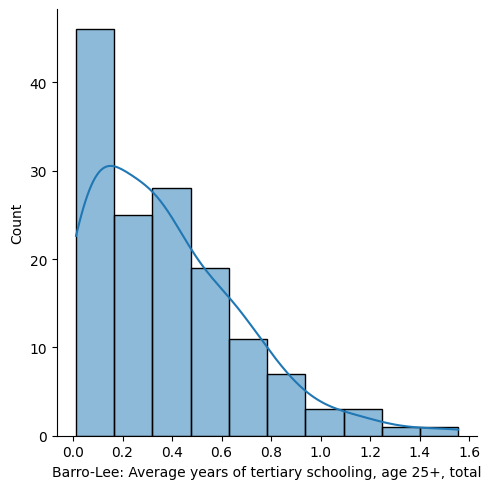


Indicateur : Gross outbound enrolment ratio, all regions, both sexes (%)


count   193.00
mean      3.39
std       7.09
min       0.06
25%       0.38
50%       1.23
75%       3.46
max      63.86
Name: Gross outbound enrolment ratio, all regions, both sexes (%), dtype: float64

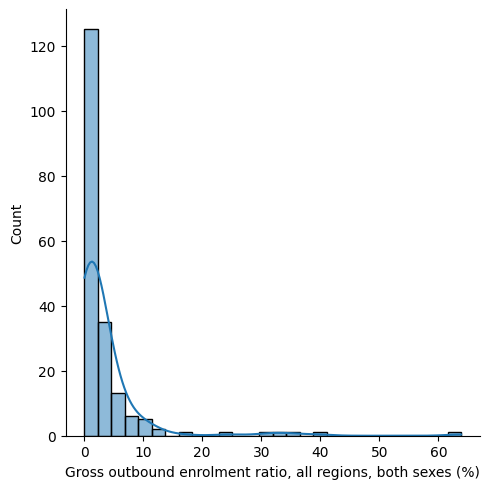


Indicateur : Official entrance age to lower secondary education (years)


count   208.00
mean     11.81
std       0.85
min      10.00
25%      11.00
50%      12.00
75%      12.00
max      14.00
Name: Official entrance age to lower secondary education (years), dtype: float64

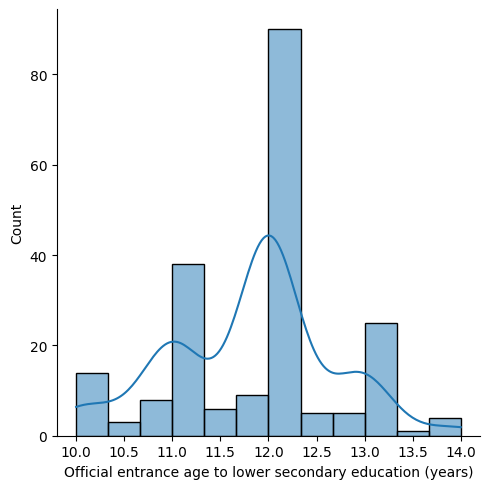


Indicateur : Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)


count   202.00
mean     97.14
std       8.44
min      18.92
25%      98.24
50%     100.00
75%     100.00
max     100.00
Name: Percentage of students in lower secondary education enrolled in general programmes, both sexes (%), dtype: float64

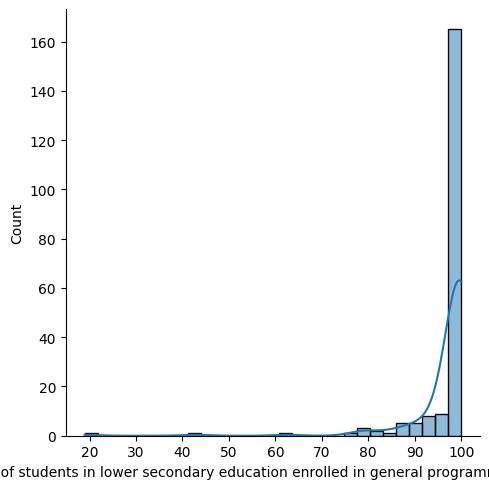


Indicateur : Theoretical duration of secondary education (years)


count   204.00
mean      6.35
std       0.86
min       4.00
25%       6.00
50%       6.00
75%       7.00
max       9.00
Name: Theoretical duration of secondary education (years), dtype: float64

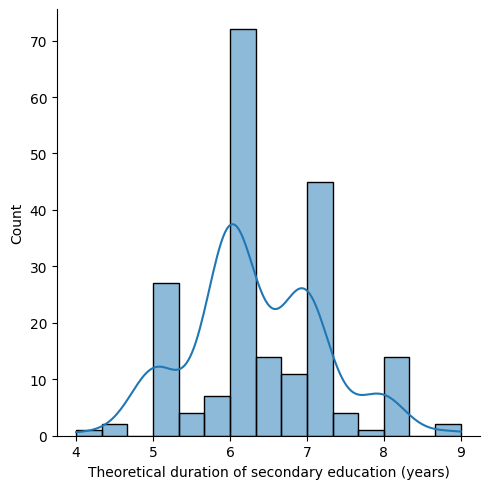


Indicateur : Theoretical duration of upper secondary education (years)


count   208.00
mean      2.96
std       0.70
min       1.00
25%       2.31
50%       3.00
75%       3.28
max       5.00
Name: Theoretical duration of upper secondary education (years), dtype: float64

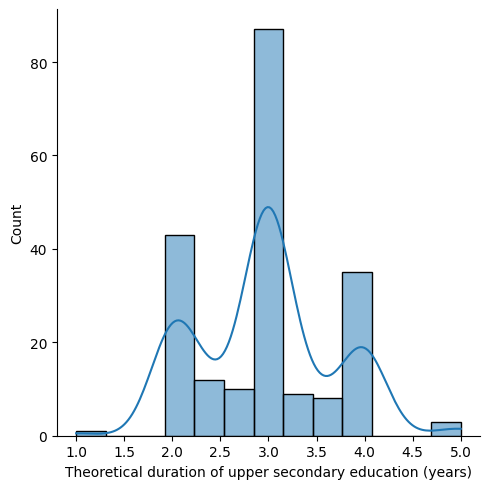


Indicateur : Wittgenstein Projection: Mean years of schooling. Age 15-19. Total


count   166.00
mean      8.22
std       2.11
min       2.15
25%       6.91
50%       8.90
75%       9.55
max      12.35
Name: Wittgenstein Projection: Mean years of schooling. Age 15-19. Total, dtype: float64

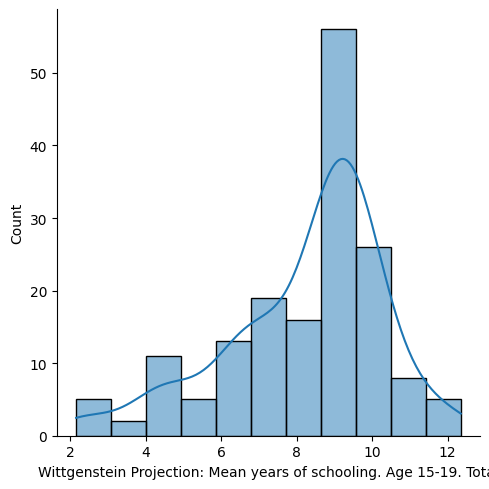

In [225]:
# création d'une boucle pour analyser la distribution de chaque indicateur sélectionné dans le dataset final.

for indicateur in dfFinal.columns:
    analyse_indicateur(dfFinal, indicateur)

##### **Interpretation de la distribuition pour chaque indicateur**

In [226]:
# resume et interpretation de chaque indicateur

interpretation_indicateurs = pd.DataFrame({

    "Indicateur": [
        "GDP per capita, PPP (constant 2011 international $)",
        "Internet users (per 100 people)",
        "Enrolment in upper secondary general, both sexes (number)",
        "Barro-Lee: Average years of tertiary schooling, age 25+, total",
        "Gross outbound enrolment ratio, all regions, both sexes (%)",
        "Official entrance age to lower secondary education (years)",
        "Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)",
        "Theoretical duration of secondary education (years)",
        "Theoretical duration of upper secondary education (years)",
        "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total"
    ],

    "Résumé Statistiques descriptives": [
        "50 % des pays ont un PIB par habitant inférieur à 8 434 $.",
        "75 % des pays comptent moins de 30 utilisateurs Internet pour 100 habitants.",
        "Forte concentration de pays avec de petits effectifs et quelques très grands marchés.",
        "50 % des pays présentent moins de 0,33 année moyenne d'enseignement supérieur.",
        "75 % des pays ont un taux inférieur à 3,13 %.",
        "La majorité des pays présentent un âge d'entrée compris entre 11 et 12 ans, avec peu d'écart entre les observations.",
        "Au moins 75 % des pays orientent la quasi-totalité de leurs élèves du secondaire inférieur vers des programmes généraux.",
        "La moitié des pays présentent une durée théorique de l'enseignement secondaire comprise entre 6 et 7 ans, avec une médiane de 6 ans et une faible dispersion globale.",
        "Dans 50 % des pays, la durée théorique de l'enseignement secondaire supérieur est comprise entre 2,3 et 3,3 ans, avec une médiane de 3 ans et peu de variations entre les systèmes éducatifs.",
        "50 % des pays ont moins de 8,9 années de scolarisation."
    ],

    "Distribution observée": [
        "Forte asymétrie à droite",
        "Asymétrie à droite",
        "Très forte asymétrie à droite",
        "Asymétrie à droite",
        "Forte asymétrie à droite",
        "Distribution concentrée",
        "Concentration proche de 100 %",
        "Distribution concentrée",
        "Distribution concentrée",
        "Distribution proche d'une loi normale"
    ],

    "Intérêt pour Academy": [
        "Les pays disposant d'un pouvoir d'achat élevé sont plus susceptibles d'investir dans des formations en ligne payantes.",
        "Un niveau élevé d'accès à Internet constitue un prérequis au développement d'une offre EdTech en ligne.",
        "Permet d'identifier les pays disposant d'un large vivier de futurs étudiants susceptibles d'accéder à l'enseignement supérieur.",
        "Mesure le niveau d'engagement de la population dans l'enseignement supérieur et l'intérêt potentiel pour les formations académiques.",
        "Peut révéler une ouverture vers les études internationales et une demande potentielle pour des formations académiques de niveau supérieur.",
        "Variable utile pour contextualiser le système éducatif mais peu pertinente pour distinguer le potentiel des marchés EdTech.",
        "Indique les pays avec une orientation académique du secondaire mais différencie peu les pays.",
        "Permet de comprendre l'organisation des parcours scolaires et de comparer les systèmes éducatifs, mais son faible niveau de variabilité limite son utilité pour identifier les marchés prioritaires.",
        "Fournit un contexte sur la durée de préparation avant l'enseignement supérieur, mais n'apporte pas d'avantage significatif pour différencier les pays à fort potentiel pour Academy.",
        "Permet d'évaluer le niveau moyen d'éducation du public cible et sa capacité à poursuivre des études supérieures."
    ],

    "Utilisé pour la sélection des pays": [
        "Oui",
        "Oui",
        "Oui",
        "Oui",
        "Oui",
        "Non",
        "Non",
        "Non",
        "Non",
        "Oui"
    ]
})

interpretation_indicateurs.index = range(1, len(interpretation_indicateurs) + 1)

display(
    interpretation_indicateurs.style
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)

,Indicateur,Résumé Statistiques descriptives,Distribution observée,Intérêt pour Academy,Utilisé pour la sélection des pays
1,"GDP per capita, PPP (constant 2011 international $)",50 % des pays ont un PIB par habitant inférieur à 8 434 $.,Forte asymétrie à droite,Les pays disposant d'un pouvoir d'achat élevé sont plus susceptibles d'investir dans des formations en ligne payantes.,Oui
2,Internet users (per 100 people),75 % des pays comptent moins de 30 utilisateurs Internet pour 100 habitants.,Asymétrie à droite,Un niveau élevé d'accès à Internet constitue un prérequis au développement d'une offre EdTech en ligne.,Oui
3,"Enrolment in upper secondary general, both sexes (number)",Forte concentration de pays avec de petits effectifs et quelques très grands marchés.,Très forte asymétrie à droite,Permet d'identifier les pays disposant d'un large vivier de futurs étudiants susceptibles d'accéder à l'enseignement supérieur.,Oui
4,"Barro-Lee: Average years of tertiary schooling, age 25+, total","50 % des pays présentent moins de 0,33 année moyenne d'enseignement supérieur.",Asymétrie à droite,Mesure le niveau d'engagement de la population dans l'enseignement supérieur et l'intérêt potentiel pour les formations académiques.,Oui
5,"Gross outbound enrolment ratio, all regions, both sexes (%)","75 % des pays ont un taux inférieur à 3,13 %.",Forte asymétrie à droite,Peut révéler une ouverture vers les études internationales et une demande potentielle pour des formations académiques de niveau supérieur.,Oui
6,Official entrance age to lower secondary education (years),"La majorité des pays présentent un âge d'entrée compris entre 11 et 12 ans, avec peu d'écart entre les observations.",Distribution concentrée,Variable utile pour contextualiser le système éducatif mais peu pertinente pour distinguer le potentiel des marchés EdTech.,Non
7,"Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)",Au moins 75 % des pays orientent la quasi-totalité de leurs élèves du secondaire inférieur vers des programmes généraux.,Concentration proche de 100 %,Indique les pays avec une orientation académique du secondaire mais différencie peu les pays.,Non
8,Theoretical duration of secondary education (years),"La moitié des pays présentent une durée théorique de l'enseignement secondaire comprise entre 6 et 7 ans, avec une médiane de 6 ans et une faible dispersion globale.",Distribution concentrée,"Permet de comprendre l'organisation des parcours scolaires et de comparer les systèmes éducatifs, mais son faible niveau de variabilité limite son utilité pour identifier les marchés prioritaires.",Non
9,Theoretical duration of upper secondary education (years),"Dans 50 % des pays, la durée théorique de l'enseignement secondaire supérieur est comprise entre 2,3 et 3,3 ans, avec une médiane de 3 ans et peu de variations entre les systèmes éducatifs.",Distribution concentrée,"Fournit un contexte sur la durée de préparation avant l'enseignement supérieur, mais n'apporte pas d'avantage significatif pour différencier les pays à fort potentiel pour Academy.",Non
10,Wittgenstein Projection: Mean years of schooling. Age 15-19. Total,"50 % des pays ont moins de 8,9 années de scolarisation.",Distribution proche d'une loi normale,Permet d'évaluer le niveau moyen d'éducation du public cible et sa capacité à poursuivre des études supérieures.,Oui


In [227]:
# resume et interpretation de chaque indicateur

interpretation_indicateurs = pd.DataFrame({

    "Indicateur": [
        "GDP per capita, PPP (constant 2011 international $)",
        "Internet users (per 100 people)",
        "Enrolment in upper secondary general, both sexes (number)",
        "Barro-Lee: Average years of tertiary schooling, age 25+, total",
        "Gross outbound enrolment ratio, all regions, both sexes (%)",
        "Official entrance age to lower secondary education (years)",
        "Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)",
        "Theoretical duration of secondary education (years)",
        "Theoretical duration of upper secondary education (years)",
        "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total"
    ],


    "Intérêt pour Academy": [
        "Les pays disposant d'un pouvoir d'achat élevé sont plus susceptibles d'investir dans des formations en ligne payantes.",
        "Un niveau élevé d'accès à Internet constitue un prérequis au développement d'une offre EdTech en ligne.",
        "Permet d'identifier les pays disposant d'un large vivier de futurs étudiants susceptibles d'accéder à l'enseignement supérieur.",
        "Mesure le niveau d'engagement de la population dans l'enseignement supérieur et l'intérêt potentiel pour les formations académiques.",
        "Peut révéler une ouverture vers les études internationales et une demande potentielle pour des formations académiques de niveau supérieur.",
        "Variable utile pour contextualiser le système éducatif mais peu pertinente pour distinguer le potentiel des marchés EdTech.",
        "Indique les pays avec une orientation académique du secondaire mais différencie peu les pays.",
        "Permet de comprendre l'organisation des parcours scolaires et de comparer les systèmes éducatifs, mais son faible niveau de variabilité limite son utilité pour identifier les marchés prioritaires.",
        "Fournit un contexte sur la durée de préparation avant l'enseignement supérieur, mais n'apporte pas d'avantage significatif pour différencier les pays à fort potentiel pour Academy.",
        "Permet d'évaluer le niveau moyen d'éducation du public cible et sa capacité à poursuivre des études supérieures."
    ],

    "Utilisé pour l'analyse finale'": [
        "Oui",
        "Oui",
        "Oui",
        "Oui",
        "Oui",
        "Non",
        "Non",
        "Non",
        "Non",
        "Oui"
    ]
})

interpretation_indicateurs.index = range(1, len(interpretation_indicateurs) + 1)

display(
    interpretation_indicateurs.style
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)

,Indicateur,Intérêt pour Academy,Utilisé pour l'analyse finale'
1,"GDP per capita, PPP (constant 2011 international $)",Les pays disposant d'un pouvoir d'achat élevé sont plus susceptibles d'investir dans des formations en ligne payantes.,Oui
2,Internet users (per 100 people),Un niveau élevé d'accès à Internet constitue un prérequis au développement d'une offre EdTech en ligne.,Oui
3,"Enrolment in upper secondary general, both sexes (number)",Permet d'identifier les pays disposant d'un large vivier de futurs étudiants susceptibles d'accéder à l'enseignement supérieur.,Oui
4,"Barro-Lee: Average years of tertiary schooling, age 25+, total",Mesure le niveau d'engagement de la population dans l'enseignement supérieur et l'intérêt potentiel pour les formations académiques.,Oui
5,"Gross outbound enrolment ratio, all regions, both sexes (%)",Peut révéler une ouverture vers les études internationales et une demande potentielle pour des formations académiques de niveau supérieur.,Oui
6,Official entrance age to lower secondary education (years),Variable utile pour contextualiser le système éducatif mais peu pertinente pour distinguer le potentiel des marchés EdTech.,Non
7,"Percentage of students in lower secondary education enrolled in general programmes, both sexes (%)",Indique les pays avec une orientation académique du secondaire mais différencie peu les pays.,Non
8,Theoretical duration of secondary education (years),"Permet de comprendre l'organisation des parcours scolaires et de comparer les systèmes éducatifs, mais son faible niveau de variabilité limite son utilité pour identifier les marchés prioritaires.",Non
9,Theoretical duration of upper secondary education (years),"Fournit un contexte sur la durée de préparation avant l'enseignement supérieur, mais n'apporte pas d'avantage significatif pour différencier les pays à fort potentiel pour Academy.",Non
10,Wittgenstein Projection: Mean years of schooling. Age 15-19. Total,Permet d'évaluer le niveau moyen d'éducation du public cible et sa capacité à poursuivre des études supérieures.,Oui


##### **Sélection des Pays par indicateur**

###### **1. GDP per capita, PPP (constant 2011 international $)** | Mésurer le pouvoir d'achat

In [228]:
#sélection des 5 pays avec le PIB par habitant le plus élevé pour visualiser les marchés potentiels les plus riches pour Academy.

top5_gdp = (
    dfFinal
    .sort_values(
        by="GDP per capita, PPP (constant 2011 international $)",
        ascending=False
    )
    .head(5)
    [["GDP per capita, PPP (constant 2011 international $)"]]
    .reset_index()
)

display(top5_gdp)

indicator_name,country_name,"GDP per capita, PPP (constant 2011 international $)"
0,Qatar,117382.12
1,United Arab Emirates,87868.97
2,Brunei Darussalam,82675.71
3,Luxembourg,80517.30
4,Kuwait,79404.92


###### **2. Internet users (per 100 people)** | Mésurer l'accessibilité à l'internet

In [229]:
# sélection des 5 pays avec le meilleur accès à Internet.

top5_internet = (
    dfFinal
    .sort_values(
        by="Internet users (per 100 people)",
        ascending=False
    )
    .head(5)
    [["Internet users (per 100 people)"]]
    .reset_index()
)

display(
    top5_internet.style
    .format({
        "Internet users (per 100 people)": "{:.2f}"
    })
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)

indicator_name,country_name,Internet users (per 100 people)
0,Liechtenstein,67.16
1,Monaco,63.31
2,Bermuda,59.49
3,Iceland,58.12
4,Norway,56.44


###### **3. Enrolment in upper secondary general, both sexes (number)** | Mésurer la taille du public lycée

In [230]:
# sélection des 5 pays avec le plus grand nombre d'élèves
# dans l'enseignement secondaire supérieur.

top5_enrolment = (
    dfFinal
    .sort_values(
        by="Enrolment in upper secondary general, both sexes (number)",
        ascending=False
    )
    .head(5)
    [["Enrolment in upper secondary general, both sexes (number)"]]
    .reset_index()
)

display(
    top5_enrolment.style
    .format({
        "Enrolment in upper secondary general, both sexes (number)": "{:,.0f}"
    })
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)

indicator_name,country_name,"Enrolment in upper secondary general, both sexes (number)"
0,India,"35,919,252"
1,China,"21,634,180"
2,United States,"11,274,648"
3,Brazil,"8,309,952"
4,Indonesia,"4,440,668"


###### **4. Barro-Lee: Average years of tertiary schooling, age 25+, total** | Mésurer l'enseignement supérieur

In [231]:
# sélection des 5 pays avec le niveau moyen d'enseignement supérieur le plus élevé.

top5_barrolee = (
    dfFinal
    .sort_values(
        by="Barro-Lee: Average years of tertiary schooling, age 25+, total",
        ascending=False
    )
    .head(5)
    [["Barro-Lee: Average years of tertiary schooling, age 25+, total"]]
    .reset_index()
)

display(
    top5_barrolee.style
    .format({
        "Barro-Lee: Average years of tertiary schooling, age 25+, total": "{:.2f}"
    })
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)

indicator_name,country_name,"Barro-Lee: Average years of tertiary schooling, age 25+, total"
0,United States,1.56
1,Russian Federation,1.37
2,Israel,1.20
3,New Zealand,1.15
4,Ukraine,1.10


###### **5. Gross outbound enrolment ratio, all regions, both sexes (%)** | Mésurer l'Intérêt pour les études'

In [232]:
# sélection des 5 pays présentant le niveau moyen de scolarisation
# le plus élevé chez les 15-19 ans.

top5_wittgenstein = (
    dfFinal
    .sort_values(
        by="Gross outbound enrolment ratio, all regions, both sexes (%)",
        ascending=False
    )
    .head(5)
    [["Gross outbound enrolment ratio, all regions, both sexes (%)"]]
    .reset_index()
)

display(
    top5_wittgenstein.style
    .format({
        "Gross outbound enrolment ratio, all regions, both sexes (%)": "{:.2f}"
    })
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)

indicator_name,country_name,"Gross outbound enrolment ratio, all regions, both sexes (%)"
0,San Marino,63.86
1,Liechtenstein,39.36
2,Cyprus,34.75
3,Tuvalu,32.97
4,Bermuda,30.50


###### **10. Wittgenstein Projection: Mean years of schooling. Age 15-19. Total** | Mésurer le niveau d'éducation du public cible

In [233]:
# sélection des 5 pays présentant le niveau moyen de scolarisation
# le plus élevé chez les 15-19 ans.

top5_wittgenstein = (
    dfFinal
    .sort_values(
        by="Wittgenstein Projection: Mean years of schooling. Age 15-19. Total",
        ascending=False
    )
    .head(5)
    [["Wittgenstein Projection: Mean years of schooling. Age 15-19. Total"]]
    .reset_index()
)

display(
    top5_wittgenstein.style
    .format({
        "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total": "{:.2f}"
    })
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)

indicator_name,country_name,Wittgenstein Projection: Mean years of schooling. Age 15-19. Total
0,New Zealand,12.35
1,Australia,12.25
2,Ireland,11.90
3,Malaysia,11.90
4,Israel,11.65


##### **Méthode quantitative proposée**

Afin d'identifier les marchés prioritaires pour Academy, nous construisons un score composite à partir des indicateurs les plus pertinents :

- Taille du marché potentiel (Enrolment) : poids 3
- Pouvoir d'achat (GDP PPP) : poids 2
- Accès à Internet : poids 2
- Niveau d'éducation des jeunes (Wittgenstein) : poids 2
- Niveau d'enseignement supérieur (Barro-Lee) : poids 1
- Ouverture internationale (Outbound ratio) : poids 1

In [234]:
# Résumé des indicateurs clés retenus pour l'analyse et la sélection des marchés prioritaires pour Academy

indicateurs_score = [
    "GDP per capita, PPP (constant 2011 international $)",
    "Internet users (per 100 people)",
    "Enrolment in upper secondary general, both sexes (number)",
    "Barro-Lee: Average years of tertiary schooling, age 25+, total",
    "Gross outbound enrolment ratio, all regions, both sexes (%)",
    "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total"
]

In [235]:
# vérification de la complétude des indicateurs clés retenus pour l'analyse et la sélection des marchés prioritaires pour Academy.

dfFinal[indicateurs_score].isna().sum()

indicator_name
GDP per capita, PPP (constant 2011 international $)                   23
Internet users (per 100 people)                                        7
Enrolment in upper secondary general, both sexes (number)             13
Barro-Lee: Average years of tertiary schooling, age 25+, total        71
Gross outbound enrolment ratio, all regions, both sexes (%)           22
Wittgenstein Projection: Mean years of schooling. Age 15-19. Total    49
dtype: int64

In [236]:
dfFinal[indicateurs_score].isna().mean().round(3) * 100

indicator_name
GDP per capita, PPP (constant 2011 international $)                  10.70
Internet users (per 100 people)                                       3.30
Enrolment in upper secondary general, both sexes (number)             6.00
Barro-Lee: Average years of tertiary schooling, age 25+, total       33.00
Gross outbound enrolment ratio, all regions, both sexes (%)          10.20
Wittgenstein Projection: Mean years of schooling. Age 15-19. Total   22.80
dtype: float64

##### **Qualité des données des indicateurs retenus**

Les six indicateurs retenus pour la sélection finale des pays présentent globalement un niveau de complétude satisfaisant.

- Les taux de valeurs manquantes varient de 3,3 % à 33,0 % selon les indicateurs.
- Les indicateurs Internet users (3,3 %) et Enrolment in upper secondary general (6,0 %) sont les plus complets.
- Aucun indicateur ne dépasse 35 % de valeurs manquantes, ce qui permet de poursuivre l'analyse sans remise en cause majeure de la qualité des données.

In [237]:
# Analyse de la complétude des indicateurs clés retenus pour l'analyse et la sélection des marchés prioritaires pour Academy.

indicateurs_score = [
    "GDP per capita, PPP (constant 2011 international $)",
    "Internet users (per 100 people)",
    "Enrolment in upper secondary general, both sexes (number)",
    "Barro-Lee: Average years of tertiary schooling, age 25+, total",
    "Gross outbound enrolment ratio, all regions, both sexes (%)",
    "Wittgenstein Projection: Mean years of schooling. Age 15-19. Total"
]

df_score = dfFinal[indicateurs_score].copy()

print("Nombre total de pays :", len(df_score))
print("Pays avec les 6 indicateurs renseignés :", len(df_score.dropna()))

Nombre total de pays : 215
Pays avec les 6 indicateurs renseignés : 127


##### **Normalisation des indicateurs**

- Les indicateurs retenus sont exprimés dans des unités très différentes (dollars, pourcentages, années de scolarisation, nombre d'élèves).

- Afin d'éviter qu'un indicateur à grande échelle domine artificiellement les résultats, une normalisation Min-Max a été appliquée.

- Chaque indicateur est ainsi ramené sur une échelle comprise entre 0 et 1 avant le calcul du score final.

In [238]:
# normalisation des indicateurs clés retenus pour l'analyse et la sélection des marchés prioritaires pour Academy.

df_score = df_score.dropna().copy()

df_score_scaled = (
    df_score - df_score.min()
) / (
    df_score.max() - df_score.min()
)

display(df_score_scaled.head())

indicator_name,"GDP per capita, PPP (constant 2011 international $)",Internet users (per 100 people),"Enrolment in upper secondary general, both sexes (number)","Barro-Lee: Average years of tertiary schooling, age 25+, total","Gross outbound enrolment ratio, all regions, both sexes (%)",Wittgenstein Projection: Mean years of schooling. Age 15-19. Total
country_name,,,,,,
Albania,0.05,0.33,0.00,0.10,0.16,0.64
Algeria,0.09,0.13,0.03,0.13,0.01,0.79
Argentina,0.13,0.36,0.04,0.21,0.00,0.66
Armenia,0.03,0.22,0.00,0.43,0.04,0.67
Australia,0.31,0.77,0.01,0.60,0.01,0.99


In [239]:
df_score_scaled.describe().loc[["min", "max"]]

indicator_name,"GDP per capita, PPP (constant 2011 international $)",Internet users (per 100 people),"Enrolment in upper secondary general, both sexes (number)","Barro-Lee: Average years of tertiary schooling, age 25+, total","Gross outbound enrolment ratio, all regions, both sexes (%)",Wittgenstein Projection: Mean years of schooling. Age 15-19. Total
min,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00


##### **Construction d'un score composite**

Afin de répondre à la problématique d'expansion internationale d'Academy, un score composite a été construit à partir des six indicateurs les plus pertinents.

Les poids ont été définis selon leur importance métier :

- **1. PIB par habitant (PPP) :** 25 %
- **2. Utilisateurs Internet :** 20 %
- **3. Taille du marché étudiant :** 20 %
- **4. Niveau moyen de scolarisation (15-19 ans) :** 15 %
- **5. Niveau d'enseignement supérieur :** 10 %
- **6. Ouverture internationale des étudiants :** 10 %

Cette approche permet d'évaluer simultanément le pouvoir d'achat, la maturité numérique, le potentiel du marché et le niveau d'éducation des pays.

In [240]:
# Construction d'un score composite pour chaque pays en utilisant une pondération basée sur l'importance relative de chaque indicateur pour le potentiel du marché EdTech.

df_score_scaled["score_academy"] = (
    df_score_scaled["GDP per capita, PPP (constant 2011 international $)"] * 0.25
    + df_score_scaled["Internet users (per 100 people)"] * 0.20
    + df_score_scaled["Enrolment in upper secondary general, both sexes (number)"] * 0.20
    + df_score_scaled["Wittgenstein Projection: Mean years of schooling. Age 15-19. Total"] * 0.15
    + df_score_scaled["Barro-Lee: Average years of tertiary schooling, age 25+, total"] * 0.10
    + df_score_scaled["Gross outbound enrolment ratio, all regions, both sexes (%)"] * 0.10
)

df_score_scaled["score_academy"].describe()

count   127.00
mean      0.24
std       0.13
min       0.00
25%       0.13
50%       0.21
75%       0.33
max       0.55
Name: score_academy, dtype: float64

In [241]:
# Construction d'un classement des pays en fonction du score composite pour identifier les marchés prioritaires pour Academy.
df_resultats = (
    df_score_scaled
    .copy()
)

df_resultats["Position"] = (
    df_resultats["score_academy"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

df_resultats = (
    df_resultats
    .sort_values("score_academy", ascending=False)
)

display(
    df_resultats.round(3)
)

indicator_name,"GDP per capita, PPP (constant 2011 international $)",Internet users (per 100 people),"Enrolment in upper secondary general, both sexes (number)","Barro-Lee: Average years of tertiary schooling, age 25+, total","Gross outbound enrolment ratio, all regions, both sexes (%)",Wittgenstein Projection: Mean years of schooling. Age 15-19. Total,score_academy,Position
country_name,,,,,,,,
Luxembourg,0.68,0.83,0.00,0.40,0.70,0.66,0.55,1
United States,0.39,0.79,0.31,1.00,0.01,0.75,0.53,2
Qatar,1.00,0.57,0.00,0.35,0.08,0.68,0.51,3
Norway,0.49,0.97,0.00,0.46,0.14,0.78,0.49,4
United Arab Emirates,0.75,0.73,0.00,0.32,0.05,0.72,0.48,5
...,...,...,...,...,...,...,...,...
Sierra Leone,0.00,0.01,0.00,0.01,0.00,0.22,0.04,123
Burundi,0.00,0.00,0.00,0.01,0.00,0.21,0.03,124
Liberia,0.00,0.01,0.00,0.08,0.01,0.03,0.01,125


In [242]:
# Tableau final de résultats avec les indicateurs clés retenus, le score composite et le classement des pays, accompagné d'une justification pour chaque indicateur.

justificatifs = {
    "GDP_PPP": "Pouvoir d'achat",
    "Internet": "Accessibilité numérique",
    "Enrolment": "Taille du public lycée",
    "Barro_Lee": "Culture enseignement supérieur",
    "Outbound": "Intérêt pour les études",
    "Wittgenstein": "Niveau d'éducation cible",
    "score_academy": "Score global",
    "Position": "Ranking"
}

df_affichage = df_resultats.copy()

df_affichage.columns = pd.MultiIndex.from_tuples([
    (col, justificatifs.get(col, ""))
    for col in df_affichage.columns
])

display(df_affichage.round(3))

,"GDP per capita, PPP (constant 2011 international $)",Internet users (per 100 people),"Enrolment in upper secondary general, both sexes (number)","Barro-Lee: Average years of tertiary schooling, age 25+, total","Gross outbound enrolment ratio, all regions, both sexes (%)",Wittgenstein Projection: Mean years of schooling. Age 15-19. Total,score_academy,Position
,,,,,,,Score global,Ranking
country_name,,,,,,,,
Luxembourg,0.68,0.83,0.00,0.40,0.70,0.66,0.55,1
United States,0.39,0.79,0.31,1.00,0.01,0.75,0.53,2
Qatar,1.00,0.57,0.00,0.35,0.08,0.68,0.51,3
Norway,0.49,0.97,0.00,0.46,0.14,0.78,0.49,4
United Arab Emirates,0.75,0.73,0.00,0.32,0.05,0.72,0.48,5
...,...,...,...,...,...,...,...,...
Sierra Leone,0.00,0.01,0.00,0.01,0.00,0.22,0.04,123
Burundi,0.00,0.00,0.00,0.01,0.00,0.21,0.03,124


##### **Recommandation pour Academy**

Sur la base du score construit à partir des six indicateurs retenus, cinq pays apparaissent comme particulièrement attractifs pour une stratégie d'expansion internationale :

1. Luxembourg
2. États-Unis
3. Qatar
4. Norvège
5. Émirats arabes unis

Ces marchés combinent un fort pouvoir d'achat, une excellente accessibilité numérique et un niveau d'éducation élevé, ce qui constitue un environnement favorable à l'adoption de formations en ligne.

Par ailleurs, des pays comme la Nouvelle-Zélande, le Canada et l'Australie représentent également des opportunités intéressantes pour une phase d'expansion ultérieure.

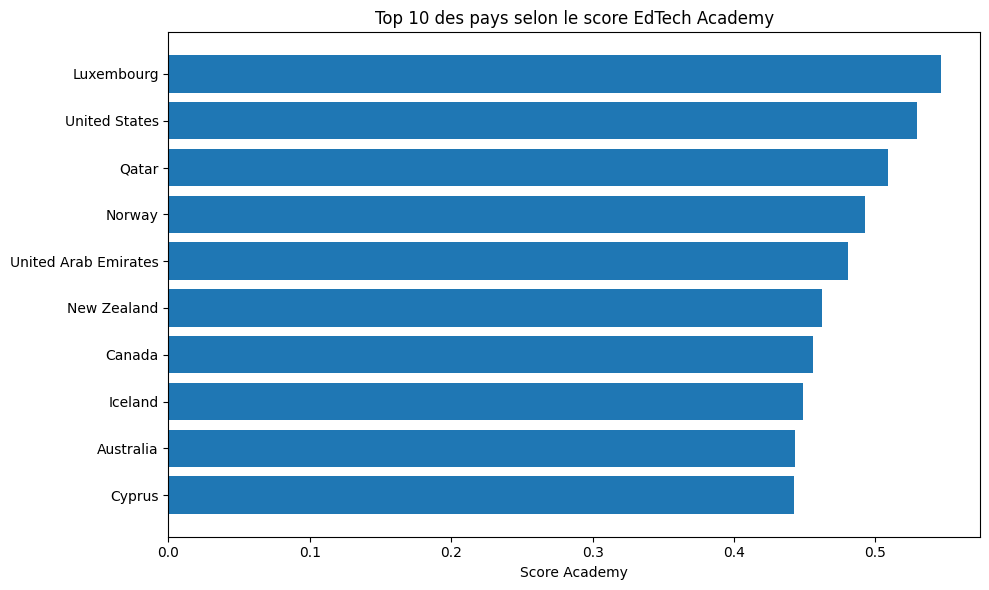

In [243]:
# TOP 10 des pays selon le score composite pour identifier les marchés prioritaires pour Academy.

top10 = (
    df_resultats
    .sort_values("score_academy", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top10.index,
    top10["score_academy"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 des pays selon le score EdTech Academy")
plt.xlabel("Score Academy")

plt.tight_layout()
plt.show()

In [244]:
# Sélection des 10 pays avec les scores composites les plus élevés pour identifier les marchés prioritaires pour Academy.

top10_pays = df_resultats.head(10)

display(top10_pays.round(3))

indicator_name,"GDP per capita, PPP (constant 2011 international $)",Internet users (per 100 people),"Enrolment in upper secondary general, both sexes (number)","Barro-Lee: Average years of tertiary schooling, age 25+, total","Gross outbound enrolment ratio, all regions, both sexes (%)",Wittgenstein Projection: Mean years of schooling. Age 15-19. Total,score_academy,Position
country_name,,,,,,,,
Luxembourg,0.68,0.83,0.00,0.40,0.70,0.66,0.55,1
United States,0.39,0.79,0.31,1.00,0.01,0.75,0.53,2
Qatar,1.00,0.57,0.00,0.35,0.08,0.68,0.51,3
Norway,0.49,0.97,0.00,0.46,0.14,0.78,0.49,4
United Arab Emirates,0.75,0.73,0.00,0.32,0.05,0.72,0.48,5
New Zealand,0.25,0.85,0.01,0.74,0.05,1.00,0.46,6
Canada,0.32,0.84,0.04,0.66,0.05,0.86,0.46,7
Iceland,0.30,1.00,0.00,0.39,0.34,0.68,0.45,8
Australia,0.30,0.77,0.01,0.60,0.01,0.99,0.44,9


In [245]:
top10_pays.reset_index()[
    ["country_name", "score_academy", "Position"]
]

indicator_name,country_name,score_academy,Position
0,Luxembourg,0.55,1
1,United States,0.53,2
2,Qatar,0.51,3
3,Norway,0.49,4
4,United Arab Emirates,0.48,5
5,New Zealand,0.46,6
6,Canada,0.46,7
7,Iceland,0.45,8
8,Australia,0.44,9
9,Cyprus,0.44,10


## **Objectfs Atendus** 

**Objectif 1 - Explorer les données éducatives de la Banque Mondiale** Exploration et compréhension des bases de données.

- EdStatsData : 886 930 lignes et 70 colonnes (51 colonnes après nettoyage).
- EdStatsSeries : 3 665 indicateurs documentés sur 21 colonnes.
- EdStatsFootNote : 643 638 lignes et 5 colonnes.
- EdStatsCountry-Series : 613 lignes et 4 colonnes.
- EdStatsCountry : 241 pays et 32 colonnes.

**Résultat :** identification de la structure des données, des indicateurs disponibles, des catégories métier et du niveau de qualité des informations avant les étapes de sélection et d'analyse.

**Objectif 2 - Nettoyer et fiabiliser les données** Réduction du périmètre des données et amélioration de leur qualité.

- Suppression des colonnes présentant plus de 95 % de valeurs manquantes.
- Standardisation des noms de colonnes.
- Exclusion de 25 faux pays identifiés à partir de la norme ISO 3166.
- Le périmètre d'analyse a ainsi été réduit de 241 à 216 pays.
- Restriction de l'analyse à la période 1990–2015, sélectionnée après analyse du taux de remplissage des données. 

**Résultat :** constitution d'un jeu de données fiable et cohérent pour l'analyse du potentiel d'expansion internationale.

**Objectif 3 - Sélectionner les indicateurs éducatifs les plus utiles** Sélection progressive des indicateurs les plus pertinents.

- Réduction du périmètre de 3 665 à 15 indicateurs, grâce à un filtrage combinant la disponibilité des données (taux de complétude) et leur pertinence métier pour évaluer le potentiel d'expansion internationale d'Academy.
- Conservation de 10 indicateurs faiblement corrélés couvrant les dimensions économiques, éducatives et numériques.
- À la fin, 6 indicateurs stratégiques ont ensuite été retenus pour la construction du score de sélection des pays, les 4 autres étant utilisés à des fins descriptives.

**Résultat :** obtention d'un ensemble d'indicateurs représentatifs du potentiel d'un marché EdTech.

**Objectif 4 - Utiliser les analyses statistiques et les visualisations pour identifier les pays à fort potentiel**

- Construction d'un score composite à partir des 6 indicateurs stratégiques retenus.
- Normalisation et pondération des indicateurs selon leur importance métier.
- Calcul d'un score global permettant de classer les pays selon leur potentiel pour le développement international d'Academy.

**Résultat :** établissement d'un classement objectif des pays permettant d'identifier les marchés les plus attractifs pour le développement international d'Academy.

- L'analyse a permis de réduire un périmètre initial de 886 930 lignes, 70 colonnes.
- Total des 241 pays à un ensemble consolidé de 215 pays pour arriver au TOP 10 pays;
- Restriction des années avec les plus grands taux de replissage des 1970 - 2100 et selection des 1990-2015.
- Il y avait 3 665 indicateurs pour arriver au TOP 10 indicateurs sélectionnés et 6 indicateurs stratégiques utilisés pour le score final.

**Recommendation :** Sur la base des 6 indicateurs stratégiques sélectionnés et du score composite construit à partir des indicateurs normalisés et pondérés, les pays obtenant les meilleurs résultats sont le Luxembourg, les États-Unis, le Qatar, la Norvègeet et les Émirats arabes unis.